# **랭체인 Multi-modal RAG 구현**


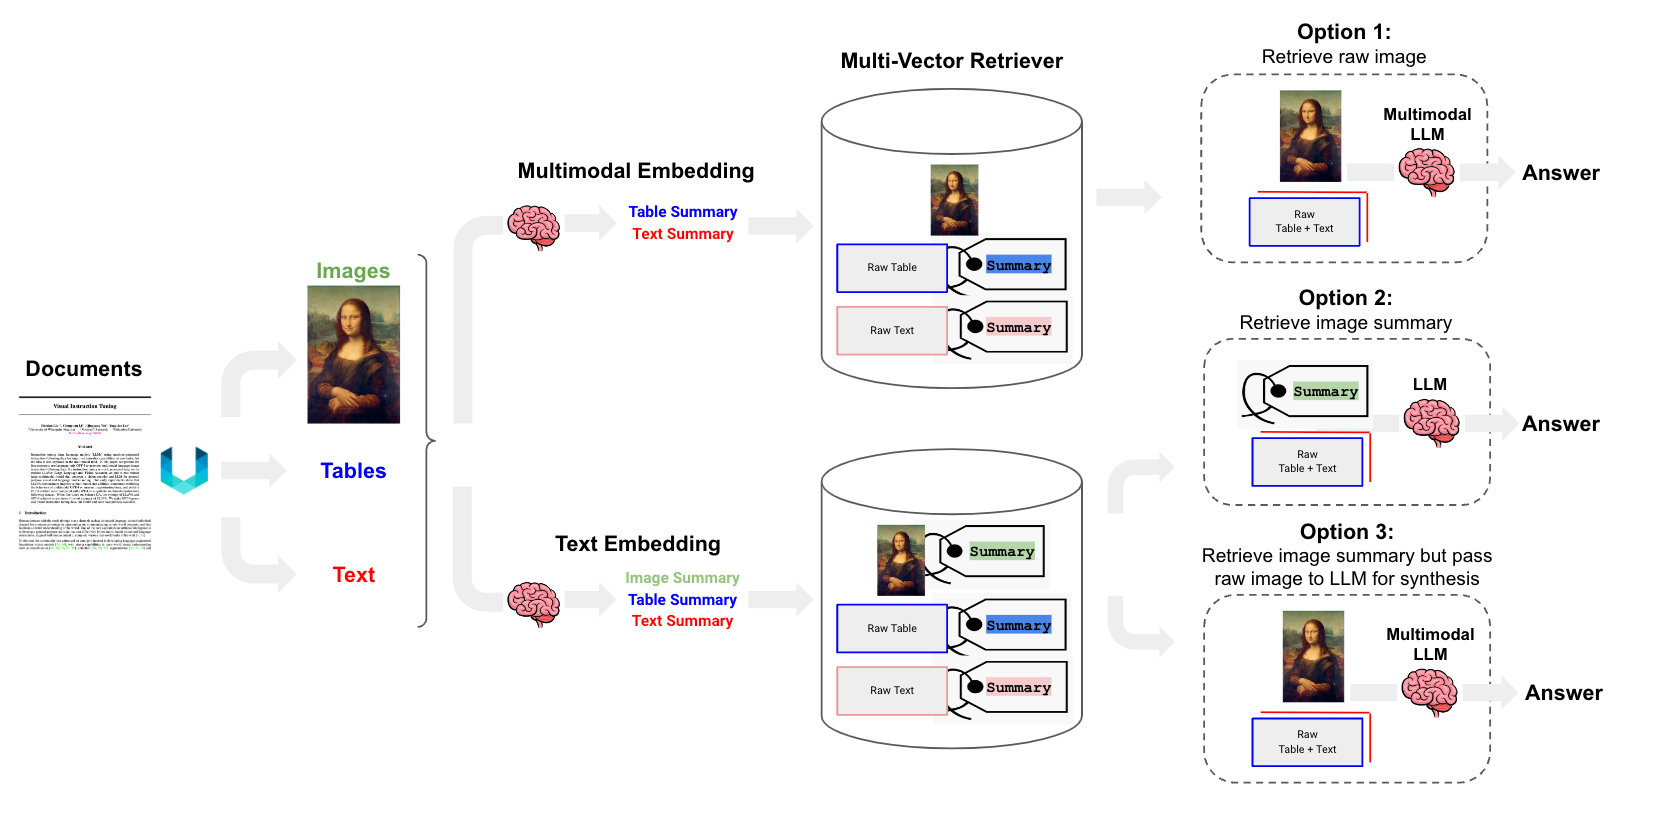

- 이미지 출처: https://github.com/langchain-ai/langchain/blob/master/cookbook/Semi_structured_and_multi_modal_RAG.ipynb

**3가지 옵션 비교:**

| 옵션 | 임베딩 방식 | 벡터 DB 저장 | 답변 생성 LLM | 이미지 활용 | 장점 | 단점 |
|---|---|---|---|---|---|---|
| 1 | 멀티모달 (CLIP) | 이미지 임베딩, 텍스트 임베딩 | Multimodal | 직접 활용 (base64) | 최고 이미지 활용도, 높은 답변 품질 | 높은 비용, base64 오버헤드 |
| 2 | 텍스트 (OpenAI) | 텍스트 임베딩 (이미지 요약) | Text-only | 텍스트 요약 간접 활용 | 비용 효율성, 텍스트 RAG 인프라 활용 | 이미지 정보 손실, 답변 품질 제한적 |
| 3 | 텍스트 (OpenAI) | 텍스트 임베딩 (이미지 요약 + 참조) | Multimodal | 원본 이미지 참조 활용 | 옵션 1과 2의 절충, 이미지 정보 손실 감소, 유연성 | 옵션 1보다 이미지 활용도 낮음, 이미지 참조 관리 필요 |

**선택 가이드:**

* **최고 품질 답변:** 옵션 1 (비용 고려)
* **비용 효율성 우선:** 옵션 2 (답변 품질 제한 감수)
* **품질과 효율성 균형:** 옵션 3

---

`(1) Env 환경변수`

In [1]:
from dotenv import load_dotenv
load_dotenv()

True

`(2) 기본 라이브러리`

In [2]:
import os
from glob import glob

from pprint import pprint
import json

import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

`(3) langfuase handler 설정`

In [3]:
from langfuse.langchain import CallbackHandler

# 콜백 핸들러 생성
langfuse_handler = CallbackHandler()

---

## **회사 소개자료 문서 로드**

- PDF 문서에서 이미지, 텍스트, 테이블 분리


### 1. **데이터 로딩 및 파싱** 

- 메모리 부족할 경우 별도의 실습파일을 활용 

In [4]:
# 데이터 저장 폴더 경로
data_path = "data/ir_reports/" 

# PDF 파일이 있는  경로
pdf_files = glob(os.path.join(data_path, "*.pdf"))  

# 이미지를 저장할 경로
image_output_dir = os.path.join(data_path, 'images')  

os.makedirs(image_output_dir, exist_ok=True)

print(f"PDF files:")
pprint(pdf_files)

PDF files:
['data/ir_reports\\SK E&S_Profile 2022(KOR).pdf']


In [5]:
from unstructured.partition.pdf import partition_pdf
from unstructured.cleaners.core import (
    clean_extra_whitespace,
    group_broken_paragraphs
)

# PDF 파일을 로드하고 파티셔닝
chunks = partition_pdf(
    filename=pdf_files[0],  # 첫 번째 PDF 파일을 선택
    strategy="hi_res",              
    infer_table_structure=True,    
    languages=["eng", "kor"],           
    
    # 이미지 추출 설정     
    extract_image_block_types=["Image", "Table"],
    extract_image_block_output_dir=image_output_dir,   # 이미지 저장 경로
    # extract_image_block_to_payload=True, # base64로 저장

    # 후처리 설정
    post_processors=[
        group_broken_paragraphs,
        clean_extra_whitespace,
        ], 

    # 문서 청킹 설정
    chunking_strategy="by_title",
    max_characters=2000,   
    new_after_n_chars=1600,
    combine_text_under_n_chars=1000,    

)

# 청크 개수 확인
print(len(chunks))

Cannot set gray non-stroke color because /'P0' is an invalid float value
Cannot set gray non-stroke color because /'P1' is an invalid float value
Cannot set gray non-stroke color because /'P2' is an invalid float value
Cannot set gray stroke color because /'P0' is an invalid float value
Cannot set gray stroke color because /'P0' is an invalid float value
Cannot set gray non-stroke color because /'P0' is an invalid float value
Cannot set gray non-stroke color because /'P1' is an invalid float value
Cannot set gray non-stroke color because /'P2' is an invalid float value
Cannot set gray stroke color because /'P0' is an invalid float value
Cannot set gray non-stroke color because /'P0' is an invalid float value
Cannot set gray non-stroke color because /'P1' is an invalid float value
Cannot set gray non-stroke color because /'P2' is an invalid float value
Cannot set gray stroke color because /'P0' is an invalid float value
Cannot set gray stroke color because /'P0' is an invalid float valu

27


In [6]:
# 청크 내용 확인
for chunk in chunks[1:3]:
    print(chunk)
    print("=" * 100)

CEO MESSAGE

SK E&S는 지난 해 팬데믹의 지속적인 확산과 에너지 시장의 급격한 변화 속에서도

全 사업 영역에서 견조한 성과를 이루어냈습니다.

특히 수소와 에너지솔루션 사업에 진출하여 미래 신에너지 시장 선점의 토대를 마련했고, Carbon Neutral LNG 사업 모델을 추진하면서 SK E&S만의 차별화된

‘그린 포트폴리오(Green Portfolio)’ 전환을 위한 첫 발을 내딛었습니다.

비상장사로서는 선제적으로 사외이사 및 전문위원회 제도를 도입하여 지배구조의 독립성과 투명성을 강화했고, ESG 중심의 자상한 기업 1호 지정, 중소기업과의 상생 협력 대통령 표창 수상, 주민 참여형 및 복지형 재생에너지 사업 개발 등 우리

사회와 함께 더 큰 행복을 만드는 노력도 지속해 왔습니다.

최근 전 세계적으로 추진되고 있는 탄소중립은 기업들에게 더욱 과감한 변화를

요구하고 있습니다.

SK E&S는 책임 있는 에너지 기업으로서 이러한 변화를 선도하는 동시에 탄소중립의 현실적 대안을 제시하는 “Carbon-Neutral Energy Optimizer”로서 그 역할을 다하고자 합니다. 깨끗하고 안전한 에너지를 안정적·효율적으로 공급하는 본연의 역할 수행뿐만 아니라, 사회가 우리에게 기대하는 환경(Environment)에 대한 역할과 이해관계자와의 상생(Social), 신뢰 관계(Governance)를 지속적으로 만들어

나갈 것입니다.

특히 2022년은 재생에너지-수소-에너지솔루션-CCUS 기술과 결합한 저탄소 LNG 사업의 유기적 연계를 통한 ‘Green Portfolio’ 구축을 가속화하는 한 해로 만들어 가겠습니다. 이를 위해 SK E&S는 신에너지 기술은 물론 글로벌 인재 등 필요한

내부 역량도 과감하게 확보하여 차별적 경쟁력을 제고해 나가겠습니다.

4

SK E&S Profile 2022

5

———————————

Join Eco, Be Energy, and Make Origins

구성원과 우리 사회가 더 행복해질 수 있도

In [7]:
# 타입별 분석
chunk_types = {}
for chunk in chunks:
    chunk_type = str(type(chunk))
    if chunk_type in chunk_types:
        chunk_types[chunk_type] += 1
    else:
        chunk_types[chunk_type] = 1

print("📋 청크 타입 분포:")
for chunk_type, count in chunk_types.items():
    print(f"  • {chunk_type.split('.')[-1].replace('>', '')}: {count}개")

📋 청크 타입 분포:
  • CompositeElement': 27개


In [8]:
# 청크 저장
import pickle

with open(os.path.join(data_path, "pdf_image_chunks.pkl"), "wb") as f:
    pickle.dump(chunks, f)

In [9]:
# 청크 로드
import pickle

with open(os.path.join(data_path, "pdf_image_chunks.pkl"), "rb") as f: 
    chunks = pickle.load(f)

# 청크 개수 확인
print(len(chunks))

27


### 2. **타입별 구조 확인** 

In [10]:
# CompositeElement 확인
chunks[0]

In [11]:
# CompositeElement는 하위 구성 요소를 포함하고 있음
chunks[1].metadata.orig_elements

In [12]:
# 이미지와 테이블 수 계산
image_count = 0
table_count = 0

for chunk in chunks:
    if hasattr(chunk, 'metadata') and hasattr(chunk.metadata, 'orig_elements'):
        for element in chunk.metadata.orig_elements:
            element_type = str(type(element))
            if 'Image' in element_type:
                image_count += 1
            elif 'Table' in element_type:
                table_count += 1

print(f"\n🖼️ 추출된 이미지: {image_count}개")
print(f"📊 추출된 테이블: {table_count}개")


🖼️ 추출된 이미지: 214개
📊 추출된 테이블: 6개


In [13]:
# Image 객체 확인
img = chunks[1].metadata.orig_elements[1]
img.to_dict()

{'type': 'Image',
 'element_id': '292a7803-b2e3-45cc-90f0-532c89795bf1',
 'text': '',
 'metadata': {'coordinates': {'points': ((-2.7926472222222603,
     493.1133730555555),
    (-2.7926472222222603, 2057.0871944444443),
    (2262.8720055555555, 2057.0871944444443),
    (2262.8720055555555, 493.1133730555555)),
   'system': 'PixelSpace',
   'layout_width': 3465,
   'layout_height': 2205},
  'last_modified': '2025-11-16T14:12:38',
  'filetype': 'PPM',
  'languages': ['eng', 'kor'],
  'page_number': 4,
  'image_path': 'data/ir_reports/images\\figure-4-6.jpg'}}

In [14]:
from PIL import Image


# 이미지 로드
img_path = img.metadata.image_path
pil_img = Image.open(img_path)

# 이미지 출력
pil_img.show()

In [15]:
# Table 요소를 포함하고 있음
chunks[-2].metadata.orig_elements

In [16]:
# Table 객체 확인
chunks[-2].metadata.orig_elements[1].to_dict()

{'type': 'Table',
 'element_id': 'b0211feb-3608-4617-aa86-cd3eee9c7ae8',
 'text': 'Overseas Network [ ASIA ] China / Beijing PRISM Energy International China Limited 22F, SK Tower, No. 6 Jia, Jianguomenwai Avenue, Beijing, China China / Hangzhou PRISM Energy International Zhoushan Building A 604, Wanxiang Enterprise Center, Shangcheng District, Hangzhou, China Singapore / Singapore City PRISM Energy International #05-07, OUE Bayfront, 50 Collyer Quay Singapore, 049321 Indonesia / Jakarta PT. PRISM NUSANTARA Gandaria 8 Office Tower 12th Jl. Sultan Iskandar, Jakarta 12240, Indonesia [ OCEANIA ] Domestic Network SK E&S 서울특별시 종로구 종로 SK (03188) 빌딩 T. 02-2121-3114 26 (서린동) 파주에너지서비스 경기도 파주시 파주읍 휴암로 T. 02-2121-3331 336-234 (10837) 나래에너지서비스 경기도 하남시 조정대로 T. 031-799-6422 77 (12919) 코원에너지서비스 서울특별시 강남구 남부순환로 T. 02-3410-8000 3165 (06332) 부산도시가스 부산광역시 수영구 황령대로 T. 051-607-1234 513 (48313) 충청에너지서비스 충청북도 청주시 흥덕구 산단로 244 (28437) 영남에너지서비스(구미) 1 경상북도 구미시 공단로 T. 054-460-6000 6 길 94 (39373) 영남에너지서비스(포항) 경상북도

In [17]:
# Table 객체를 pandas DataFrame으로 변환
tab = chunks[-2].metadata.orig_elements[1]
tab_df = pd.read_html(tab.metadata.text_as_html)[0]

tab_df.head()

,[ASIA],SK E&S,영 남 에 너 지 서 비 스 (구미)
0,China / Beijing,서 울 특별시 종로구 SE 26 (서린동),경상북도 구미시 1 공 단 로 6 길 94 (39373)
1,PRISM Energy International China,96《 빌 딩 (03188),. 054-460-6000
2,"Limited 22F, SK Tower, No. 6 Jia,",: 02-2121-3114,NaN
3,"Jianguomenwai Avenue, Beijing, China",NaN,영 남 에 너 지 서 비 스 (포항)
4,China / Hangzhou,파 주 에 너 지 서비스 경기도 파주시 파주읍 Bot 로 336-234 (10837),경상북도 포항시 북구 소 티 재로 208 (37635) .054-280-5114


In [18]:
# Table 객체를 마크다운 형식으로 변환
tab_md = tab_df.to_markdown()
print(tab_md)

|    | [ASIA]                                      | SK E&S                                                            | 영 남 에 너 지 서 비 스 (구미)                                   |
|---:|:--------------------------------------------|:------------------------------------------------------------------|:-----------------------------------------------------------------|
|  0 | China / Beijing                             | 서 울 특별시 종로구 SE 26 (서린동)                                | 경상북도 구미시 1 공 단 로 6 길 94 (39373)                       |
|  1 | PRISM Energy International China            | 96《 빌 딩 (03188)                                                | . 054-460-6000                                                   |
|  2 | Limited 22F, SK Tower, No. 6 Jia,           | : 02-2121-3114                                                    | nan                                                              |
|  3 | Jianguomenwai Avenue, Beijing, China        | nan                                       

In [19]:
# Table 객체 이미지 확인
pil_img = Image.open(tab.metadata.image_path)

# 이미지 출력
pil_img.show()

---

## **[옵션 1]** 멀티모달 임베딩 (CLIP) 사용

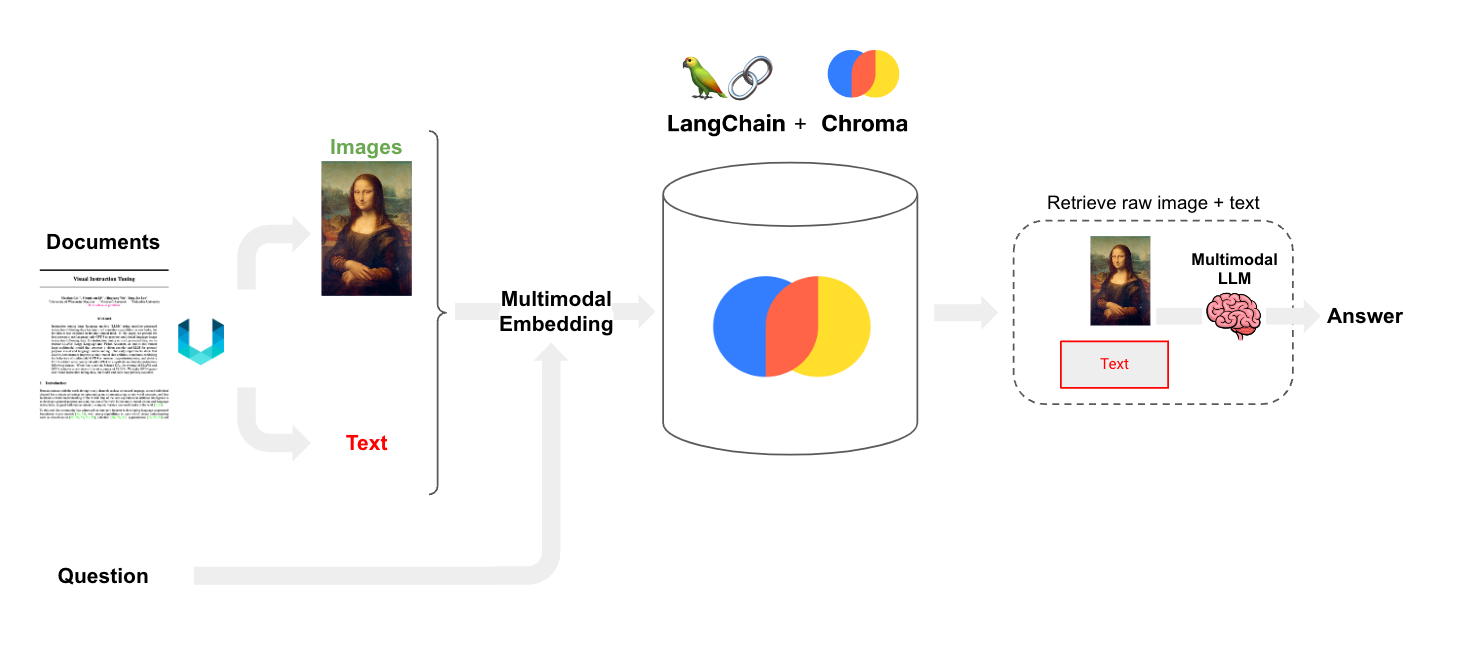

- 이미지 출처: https://github.com/langchain-ai/langchain/blob/master/cookbook/multi_modal_RAG_chroma.ipynb

### 1. **임베딩 변환 및 인덱싱** 

- Table, Text 요소를 모두 같은 임베딩 모델을 사용하여 변환

`(1) 다국어 CLIP 모델 준비`

In [30]:
import shutil; shutil.rmtree('./models/xlm_roberta_vit_b32')

In [31]:
import os
import subprocess
from langchain_experimental.open_clip import OpenCLIPEmbeddings

# 다국어 CLIP 모델 로컬 다운로드
multilingual_model_dir = "./models/xlm_roberta_vit_b32"

if not os.path.exists(multilingual_model_dir):
    print("다국어 CLIP 모델 다운로드 중...")
    print("⚠️ huggingface-cli를 사용하여 다운로드합니다. 약 5-15분 소요될 수 있습니다.")
    
    # huggingface-cli로 다운로드 (tqdm 문제 회피)
    cmd = [
        "huggingface-cli",
        "download",
        "laion/CLIP-ViT-B-32-xlm-roberta-base-laion5B-s13B-b90k",
        "--local-dir", multilingual_model_dir,
        "--local-dir-use-symlinks", "False"
    ]
    
    try:
        result = subprocess.run(
            cmd,
            check=True,
            capture_output=True,
            text=True
        )
        print("✅ 다운로드 완료!")
        if result.stdout:
            print(result.stdout)
    except subprocess.CalledProcessError as e:
        print(f"❌ 다운로드 실패: {e}")
        print(f"stderr: {e.stderr}")
        raise
    except FileNotFoundError:
        print("❌ huggingface-cli를 찾을 수 없습니다.")
        print("   설치: pip install -U huggingface_hub")
        raise
else:
    print(f"모델이 이미 존재합니다: {multilingual_model_dir}")

# 디버깅: 디렉토리 내 파일 목록 확인
print(f"\n📁 디렉토리 내 파일 목록:")
if os.path.exists(multilingual_model_dir):
    all_files = os.listdir(multilingual_model_dir)
    print(f"   전체 파일 개수: {len(all_files)}")
    
    # .bin과 .safetensors 파일만 필터링
    model_files = [f for f in all_files if f.endswith('.bin') or f.endswith('.safetensors')]
    if model_files:
        print(f"   모델 파일 ({len(model_files)}개):")
        for f in model_files:
            print(f"   - {f}")
    else:
        print(f"   ⚠️ .bin 또는 .safetensors 파일이 없습니다.")
        print(f"   디렉토리 내 파일 (처음 10개):")
        for f in all_files[:10]:
            print(f"   - {f}")
else:
    print(f"   ⚠️ 디렉토리가 존재하지 않습니다.")

# 체크포인트 파일 자동 탐지
checkpoint_files = [
    f"{multilingual_model_dir}/open_clip_pytorch_model.bin",
    f"{multilingual_model_dir}/pytorch_model.bin",
    f"{multilingual_model_dir}/model.safetensors",
    f"{multilingual_model_dir}/open_clip_model.safetensors"
]

checkpoint_path = None
for cp_file in checkpoint_files:
    if os.path.exists(cp_file):
        checkpoint_path = cp_file
        print(f"\n✅ 체크포인트 파일 발견: {checkpoint_path}")
        break

if checkpoint_path is None:
    # 디렉토리 내 .bin 또는 .safetensors 파일 검색
    print(f"\n🔍 대체 체크포인트 파일 검색 중...")
    for f in os.listdir(multilingual_model_dir):
        if f.endswith('.bin') or f.endswith('.safetensors'):
            checkpoint_path = os.path.join(multilingual_model_dir, f)
            print(f"✅ 체크포인트 파일 발견: {checkpoint_path}")
            break

if checkpoint_path is None:
    print(f"\n❌ 체크포인트 파일을 찾을 수 없습니다.")
    print(f"   해결 방법:")
    print(f"   1. 디렉토리 삭제: import shutil; shutil.rmtree('{multilingual_model_dir}')")
    print(f"   2. 셀 다시 실행하여 재다운로드")
    raise FileNotFoundError(f"체크포인트 파일을 찾을 수 없습니다: {multilingual_model_dir}")

# OpenCLIPEmbeddings 임베딩 모델 초기화 (로컬 체크포인트 사용)
print(f"\n🔧 OpenCLIPEmbeddings 초기화 중...")
print(f"   모델명: xlm-roberta-base-ViT-B-32")
print(f"   체크포인트: {checkpoint_path}")

clip_embedding_model = OpenCLIPEmbeddings(
    model_name="xlm-roberta-base-ViT-B-32",
    checkpoint=checkpoint_path,
)  #type: ignore

print("✅ 다국어 CLIP 임베딩 모델 로드 완료!")

다국어 CLIP 모델 다운로드 중...
⚠️ huggingface-cli를 사용하여 다운로드합니다. 약 5-15분 소요될 수 있습니다.
✅ 다운로드 완료!
⚠️  Warning: 'huggingface-cli download' is deprecated. Use 'hf download' instead.
F:\대학과제\25-하반기\8_모연_재직자_LLM\PRJ_04\Week2_20251118_20251122\models\xlm_roberta_vit_b32


📁 디렉토리 내 파일 목록:
   전체 파일 개수: 8
   모델 파일 (1개):
   - open_clip_pytorch_model.bin

✅ 체크포인트 파일 발견: ./models/xlm_roberta_vit_b32/open_clip_pytorch_model.bin

🔧 OpenCLIPEmbeddings 초기화 중...
   모델명: xlm-roberta-base-ViT-B-32
   체크포인트: ./models/xlm_roberta_vit_b32/open_clip_pytorch_model.bin


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

✅ 다국어 CLIP 임베딩 모델 로드 완료!


In [32]:
import os
from huggingface_hub import snapshot_download
from langchain_experimental.open_clip import OpenCLIPEmbeddings

# 다국어 CLIP 모델 로컬 다운로드 (snapshot_download 사용)
multilingual_model_dir = "./models/xlm_roberta_vit_b32"

if not os.path.exists(multilingual_model_dir):
    print("다국어 CLIP 모델 다운로드 중...")
    print("⚠️ 진행률 표시 없이 다운로드됩니다. 약 5-15분 소요될 수 있습니다.")
    
    # tqdm 비활성화를 위한 환경 변수 설정
    os.environ['HF_HUB_DISABLE_PROGRESS_BARS'] = '1'
    
    try:
        snapshot_download(
            repo_id="laion/CLIP-ViT-B-32-xlm-roberta-base-laion5B-s13B-b90k",
            local_dir=multilingual_model_dir,
            local_dir_use_symlinks=False
        )
        print("✅ 다운로드 완료!")
    finally:
        # 환경 변수 복원
        if 'HF_HUB_DISABLE_PROGRESS_BARS' in os.environ:
            del os.environ['HF_HUB_DISABLE_PROGRESS_BARS']
else:
    print(f"모델이 이미 존재합니다: {multilingual_model_dir}")

# 디버깅: 디렉토리 내 파일 목록 확인
print(f"\n📁 디렉토리 내 파일 목록:")
if os.path.exists(multilingual_model_dir):
    all_files = os.listdir(multilingual_model_dir)
    print(f"   전체 파일 개수: {len(all_files)}")
    
    # .bin과 .safetensors 파일만 필터링
    model_files = [f for f in all_files if f.endswith('.bin') or f.endswith('.safetensors')]
    if model_files:
        print(f"   모델 파일 ({len(model_files)}개):")
        for f in model_files:
            print(f"   - {f}")
    else:
        print(f"   ⚠️ .bin 또는 .safetensors 파일이 없습니다.")
        print(f"   디렉토리 내 파일 (처음 10개):")
        for f in all_files[:10]:
            print(f"   - {f}")
else:
    print(f"   ⚠️ 디렉토리가 존재하지 않습니다.")

# 체크포인트 파일 자동 탐지
checkpoint_files = [
    f"{multilingual_model_dir}/open_clip_pytorch_model.bin",
    f"{multilingual_model_dir}/pytorch_model.bin",
    f"{multilingual_model_dir}/model.safetensors",
    f"{multilingual_model_dir}/open_clip_model.safetensors"
]

checkpoint_path = None
for cp_file in checkpoint_files:
    if os.path.exists(cp_file):
        checkpoint_path = cp_file
        print(f"\n✅ 체크포인트 파일 발견: {checkpoint_path}")
        break

if checkpoint_path is None:
    # 디렉토리 내 .bin 또는 .safetensors 파일 검색
    print(f"\n🔍 대체 체크포인트 파일 검색 중...")
    for f in os.listdir(multilingual_model_dir):
        if f.endswith('.bin') or f.endswith('.safetensors'):
            checkpoint_path = os.path.join(multilingual_model_dir, f)
            print(f"✅ 체크포인트 파일 발견: {checkpoint_path}")
            break

if checkpoint_path is None:
    print(f"\n❌ 체크포인트 파일을 찾을 수 없습니다.")
    print(f"   해결 방법:")
    print(f"   1. 디렉토리 삭제: import shutil; shutil.rmtree('{multilingual_model_dir}')")
    print(f"   2. 셀 다시 실행하여 재다운로드")
    raise FileNotFoundError(f"체크포인트 파일을 찾을 수 없습니다: {multilingual_model_dir}")

# OpenCLIPEmbeddings 임베딩 모델 초기화 (로컬 체크포인트 사용)
print(f"\n🔧 OpenCLIPEmbeddings 초기화 중...")
print(f"   모델명: xlm-roberta-base-ViT-B-32")
print(f"   체크포인트: {checkpoint_path}")

clip_embedding_model = OpenCLIPEmbeddings(
    model_name="xlm-roberta-base-ViT-B-32",
    checkpoint=checkpoint_path,
)  #type: ignore

print("✅ 다국어 CLIP 임베딩 모델 로드 완료!")

모델이 이미 존재합니다: ./models/xlm_roberta_vit_b32

📁 디렉토리 내 파일 목록:
   전체 파일 개수: 8
   모델 파일 (1개):
   - open_clip_pytorch_model.bin

✅ 체크포인트 파일 발견: ./models/xlm_roberta_vit_b32/open_clip_pytorch_model.bin

🔧 OpenCLIPEmbeddings 초기화 중...
   모델명: xlm-roberta-base-ViT-B-32
   체크포인트: ./models/xlm_roberta_vit_b32/open_clip_pytorch_model.bin
✅ 다국어 CLIP 임베딩 모델 로드 완료!


In [33]:
import os
from huggingface_hub import snapshot_download
from langchain_experimental.open_clip import OpenCLIPEmbeddings

# 다국어 CLIP 모델 로컬 다운로드 (snapshot_download 사용)
multilingual_model_dir = "./models/xlm_roberta_vit_b32"

if not os.path.exists(multilingual_model_dir):
    print("다국어 CLIP 모델 다운로드 중...")
    snapshot_download(
        repo_id="laion/CLIP-ViT-B-32-xlm-roberta-base-laion5B-s13B-b90k",
        local_dir=multilingual_model_dir,
        local_dir_use_symlinks=False
    )
    print("다운로드 완료!")
else:
    print(f"모델이 이미 존재합니다: {multilingual_model_dir}")

# 디버깅: 디렉토리 내 파일 목록 확인
print(f"\n📁 디렉토리 내 파일 목록:")
if os.path.exists(multilingual_model_dir):
    all_files = os.listdir(multilingual_model_dir)
    print(f"   전체 파일 개수: {len(all_files)}")
    
    # .bin과 .safetensors 파일만 필터링
    model_files = [f for f in all_files if f.endswith('.bin') or f.endswith('.safetensors')]
    if model_files:
        print(f"   모델 파일 ({len(model_files)}개):")
        for f in model_files:
            print(f"   - {f}")
    else:
        print(f"   ⚠️ .bin 또는 .safetensors 파일이 없습니다.")
        print(f"   디렉토리 내 파일 (처음 10개):")
        for f in all_files[:10]:
            print(f"   - {f}")
else:
    print(f"   ⚠️ 디렉토리가 존재하지 않습니다.")

# 체크포인트 파일 자동 탐지
checkpoint_files = [
    f"{multilingual_model_dir}/open_clip_pytorch_model.bin",
    f"{multilingual_model_dir}/pytorch_model.bin",
    f"{multilingual_model_dir}/model.safetensors",
    f"{multilingual_model_dir}/open_clip_model.safetensors"
]

checkpoint_path = None
for cp_file in checkpoint_files:
    if os.path.exists(cp_file):
        checkpoint_path = cp_file
        print(f"\n✅ 체크포인트 파일 발견: {checkpoint_path}")
        break

if checkpoint_path is None:
    # 디렉토리 내 .bin 또는 .safetensors 파일 검색
    print(f"\n🔍 대체 체크포인트 파일 검색 중...")
    for f in os.listdir(multilingual_model_dir):
        if f.endswith('.bin') or f.endswith('.safetensors'):
            checkpoint_path = os.path.join(multilingual_model_dir, f)
            print(f"✅ 체크포인트 파일 발견: {checkpoint_path}")
            break

if checkpoint_path is None:
    print(f"\n❌ 체크포인트 파일을 찾을 수 없습니다.")
    print(f"   해결 방법:")
    print(f"   1. 디렉토리 삭제: import shutil; shutil.rmtree('{multilingual_model_dir}')")
    print(f"   2. 셀 다시 실행하여 재다운로드")
    raise FileNotFoundError(f"체크포인트 파일을 찾을 수 없습니다: {multilingual_model_dir}")

# OpenCLIPEmbeddings 임베딩 모델 초기화 (로컬 체크포인트 사용)
print(f"\n🔧 OpenCLIPEmbeddings 초기화 중...")
print(f"   모델명: xlm-roberta-base-ViT-B-32")
print(f"   체크포인트: {checkpoint_path}")

clip_embedding_model = OpenCLIPEmbeddings(
    model_name="xlm-roberta-base-ViT-B-32",
    checkpoint=checkpoint_path,
)  #type: ignore

print("✅ 다국어 CLIP 임베딩 모델 로드 완료!")

모델이 이미 존재합니다: ./models/xlm_roberta_vit_b32

📁 디렉토리 내 파일 목록:
   전체 파일 개수: 8
   모델 파일 (1개):
   - open_clip_pytorch_model.bin

✅ 체크포인트 파일 발견: ./models/xlm_roberta_vit_b32/open_clip_pytorch_model.bin

🔧 OpenCLIPEmbeddings 초기화 중...
   모델명: xlm-roberta-base-ViT-B-32
   체크포인트: ./models/xlm_roberta_vit_b32/open_clip_pytorch_model.bin
✅ 다국어 CLIP 임베딩 모델 로드 완료!


In [34]:
# 이미지 임베딩 
img_embedding = clip_embedding_model.embed_image([img.metadata.image_path, tab.metadata.image_path])
img_embedding = np.array(img_embedding)
print(img_embedding.shape)

(2, 512)


In [35]:
# 텍스트 임베딩
text_embedding = clip_embedding_model.embed_documents(["businessman", tab.text])
text_embedding = np.array(text_embedding)
print(text_embedding.shape)

(2, 512)


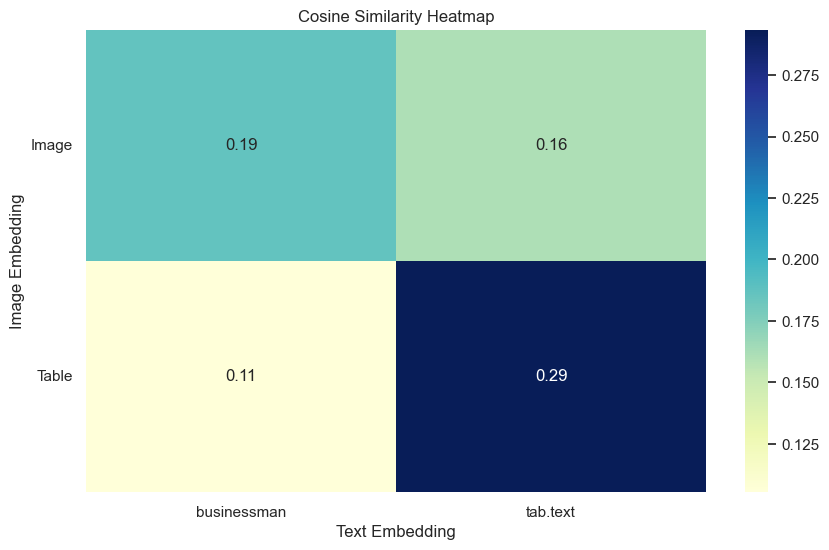

In [38]:
# 유사도 계산
from sklearn.metrics.pairwise import cosine_similarity
similarity = cosine_similarity(img_embedding, text_embedding)

# 유사도 시각화
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.heatmap(similarity, annot=True, cmap="YlGnBu", cbar=True)
plt.title("Cosine Similarity Heatmap")
plt.xlabel("Text Embedding")
plt.ylabel("Image Embedding")
plt.xticks(ticks=[0.5, 1.5], labels=["businessman", "tab.text"])
plt.yticks(ticks=[0.5, 1.5], labels=["Image", "Table"] , rotation=0)
plt.show()

`(2) DB 인덱싱`

- **멀티모달 임베딩**을 활용하여 문서와 이미지를 함께 처리
- **Chroma** 벡터 데이터베이스를 생성하여 **OpenCLIPEmbeddings**를 임베딩 함수로 사용

In [47]:
from langchain_chroma import Chroma

# Chroma DB 초기화
vectorstore = Chroma(
    collection_name="mm_rag_clip_ir", embedding_function=clip_embedding_model
)

# PDF 파일에서 추출한 이미지 경로 (jpg 파일)
image_uris = sorted(
    [
        os.path.join(image_output_dir, image_name)
        for image_name in os.listdir(image_output_dir)
        if image_name.endswith(".jpg")
    ]
)

# 이미지를 벡터스토어에 추가
vectorstore.add_images(uris=image_uris)

# 텍스트를 벡터스토어에 추가
vectorstore.add_texts(texts=[chunk.text for chunk in chunks])

# 벡터스토어 검색을 위한 retriever 생성
retriever = vectorstore.as_retriever()

### 2. **RAG** 

- **vectorstore.add_images** 함수는 이미지를 **base64 인코딩 문자열**로 저장
- 이미지가 벡터스토어에 저장될 때 원본 형식이 아닌 **인코딩된 형태**로 변환됨 
- 검색(retrieval) 시에도 이미지는 **base64 문자열**로 반환
- 필요한 경우 반환된 base64 문자열을 다시 **디코딩**하여 원본 이미지로 변환 가능

`(1) 전처리 함수`

- **is_base64()** 함수는 문자열이 Base64로 인코딩되었는지 확인
- **split_image_text_types()** 함수는 문서 배열에서 이미지와 텍스트를 분리하여 각각 별도의 배열로 저장

In [40]:
import base64
import io
from io import BytesIO

import numpy as np
from PIL import Image
from IPython.display import HTML, display
from langchain_core.documents import Document


def is_base64(s):
    """문자열이 Base64로 인코딩되었는지 확인합니다"""
    try:
        return base64.b64encode(base64.b64decode(s)) == s.encode()
    except Exception:
        return False


def split_image_text_types(docs):
    """numpy 배열 이미지와 텍스트를 분리합니다"""
    images = []
    text = []
    for doc in docs:
        if isinstance(doc, str):
            pass
        elif isinstance(doc, Document):
            doc = doc.page_content  # 문서 내용 추출
        else:
            doc = doc.text # 문서 내용 추출

        if is_base64(doc):
            # 서버 오류를 방지하기 위해 이미지 크기 조정 
            images.append(doc)  # base64로 인코딩된 문자열
        else:
            text.append(doc)
    return {"images": images, "texts": text}


def plt_img_base64(img_base64):
    """
    Base64로 인코딩된 이미지를 주피터 노트북에 표시
    
    매개변수:
    img_base64 (str): Base64로 인코딩된 이미지 문자열
    """
    # Base64 문자열을 소스로 하는 HTML img 태그 생성
    image_html = f'<img src="data:image/jpeg;base64,{img_base64}" />'

    # HTML을 렌더링하여 이미지 표시
    display(HTML(image_html))
    

GOVERNANCE ORGANIZATION

BUSINESS OVERVIEW AT A GL
———

CORPORATE SUSTAINABILITY ESG MANAGEMENT MILES
ESG MANAGEMENT

친환경 에너지 사업의 글로벌 리더로 도약하기 위해 ESG(En
풍력 발전

풍력 발전 전남 신안과 강원 평창에서 대규모 육상 풍력발전 프로젝트를 운영 중
CEO MESSAGE

SK E&S는 지난 해 팬데믹의 지속적인 확산과 에너지 시장의 급격
WWW.SKENS.COM

J

o

i

n

E

c

o

,

B

e

E

n

GREEN PORTFOLIO

:

：

:

수소 연 료 전지 발 전 을 통한 재 생 에
13

Join Eco, Be Energy, and Make Origins

SK E&S 
FSC®: Forest Stewardship Council®, 세계산림관리협의회

ECF:
부 산 정 관 에너지 인수

부산정관에너지 인수

2020년 말 인수한 부산정관에너지는 부
수 소 에너지 사업

수소에너지 사업

9.9%

2 20211418 투 자 당시 기 준 
FINANCIAL STORY

SK E&S는 청정수소와 재생에너지, 에너지 솔루션, LNG
SK E&S FAMILY

Overseas Network [ ASIA ] China / B
SK E&S 대 표 이사 부회장 유 정 준 / 대 표 이사 사장 추 형 욱

SK E&S 
주 민 참여형 발 전 사 업

… _

주민참여형 발전사업 SK E&S가 추진하는 재생에너
미국 Key Capture Energy 인수 및

에너지 솔루션 사업 진출

SK E&S는
CITY GAS BUSINESS

SK E&S는 전국 8개 지역, 총 456만 가구에 안전
미국

PRISM Energy International

7

7

United State
• 신규 사업

- 타 양 광 발 전 사 업 , 스 팀 사업

- 태양광발전사업, 스팀사업
1999 - 2010

1999.1

SK, Enron 


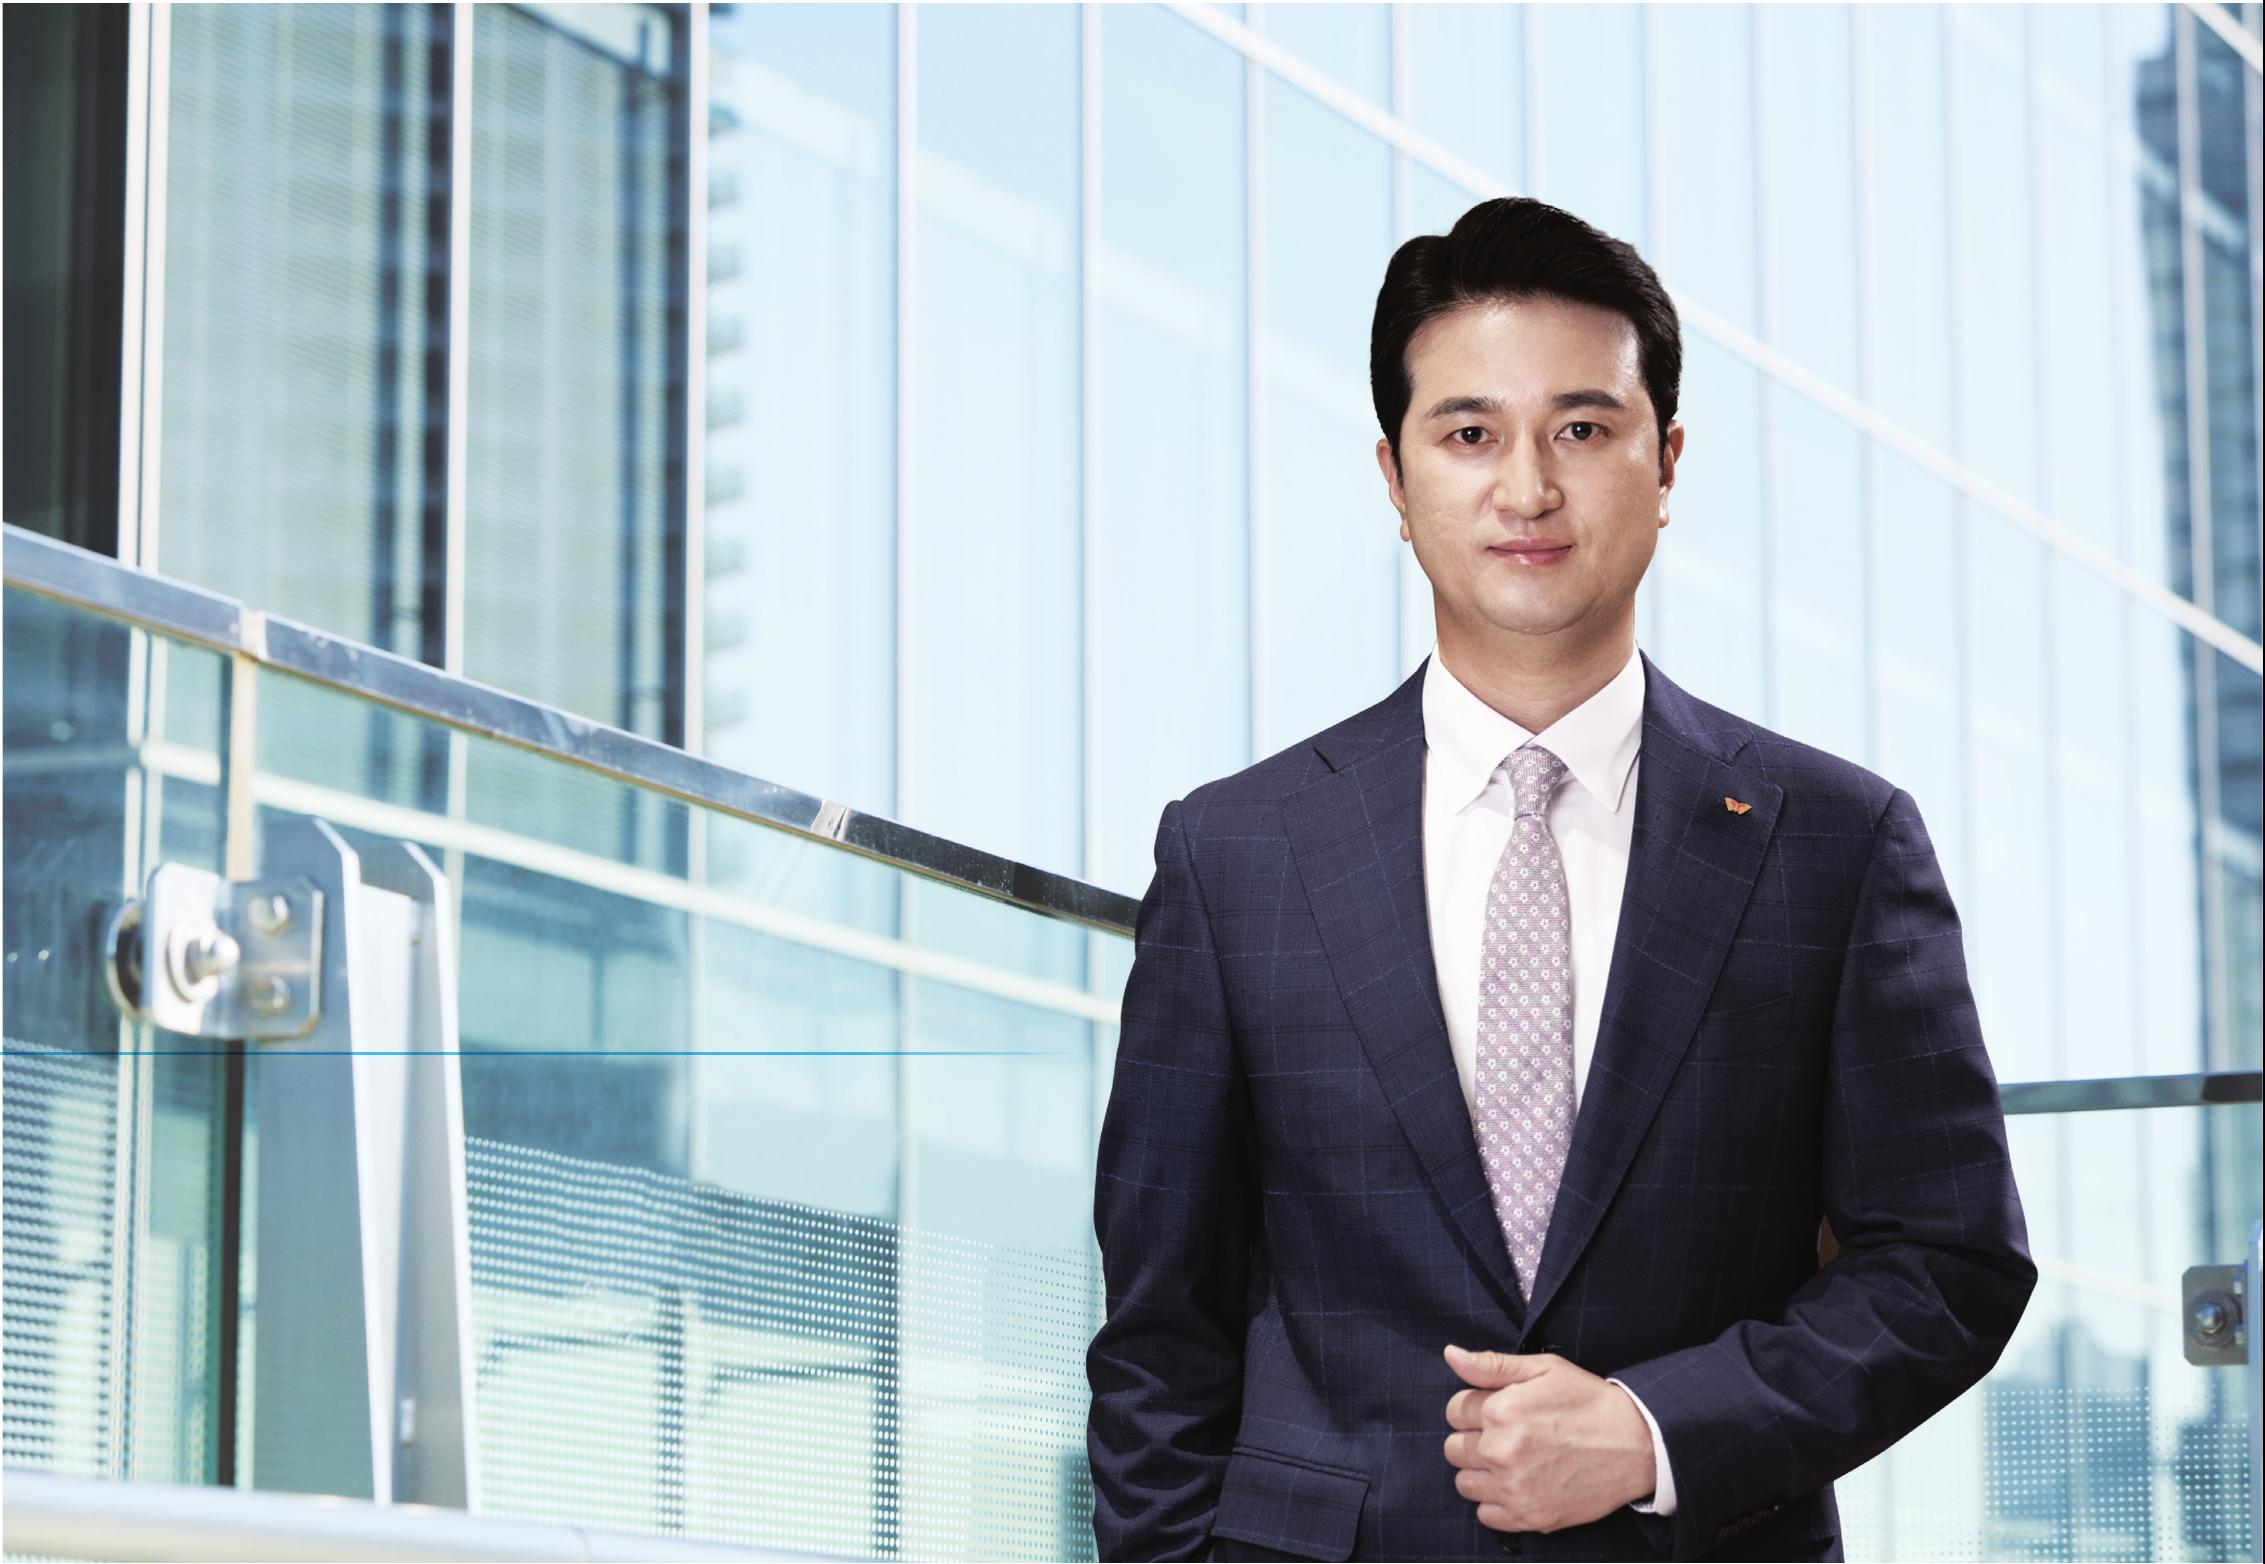


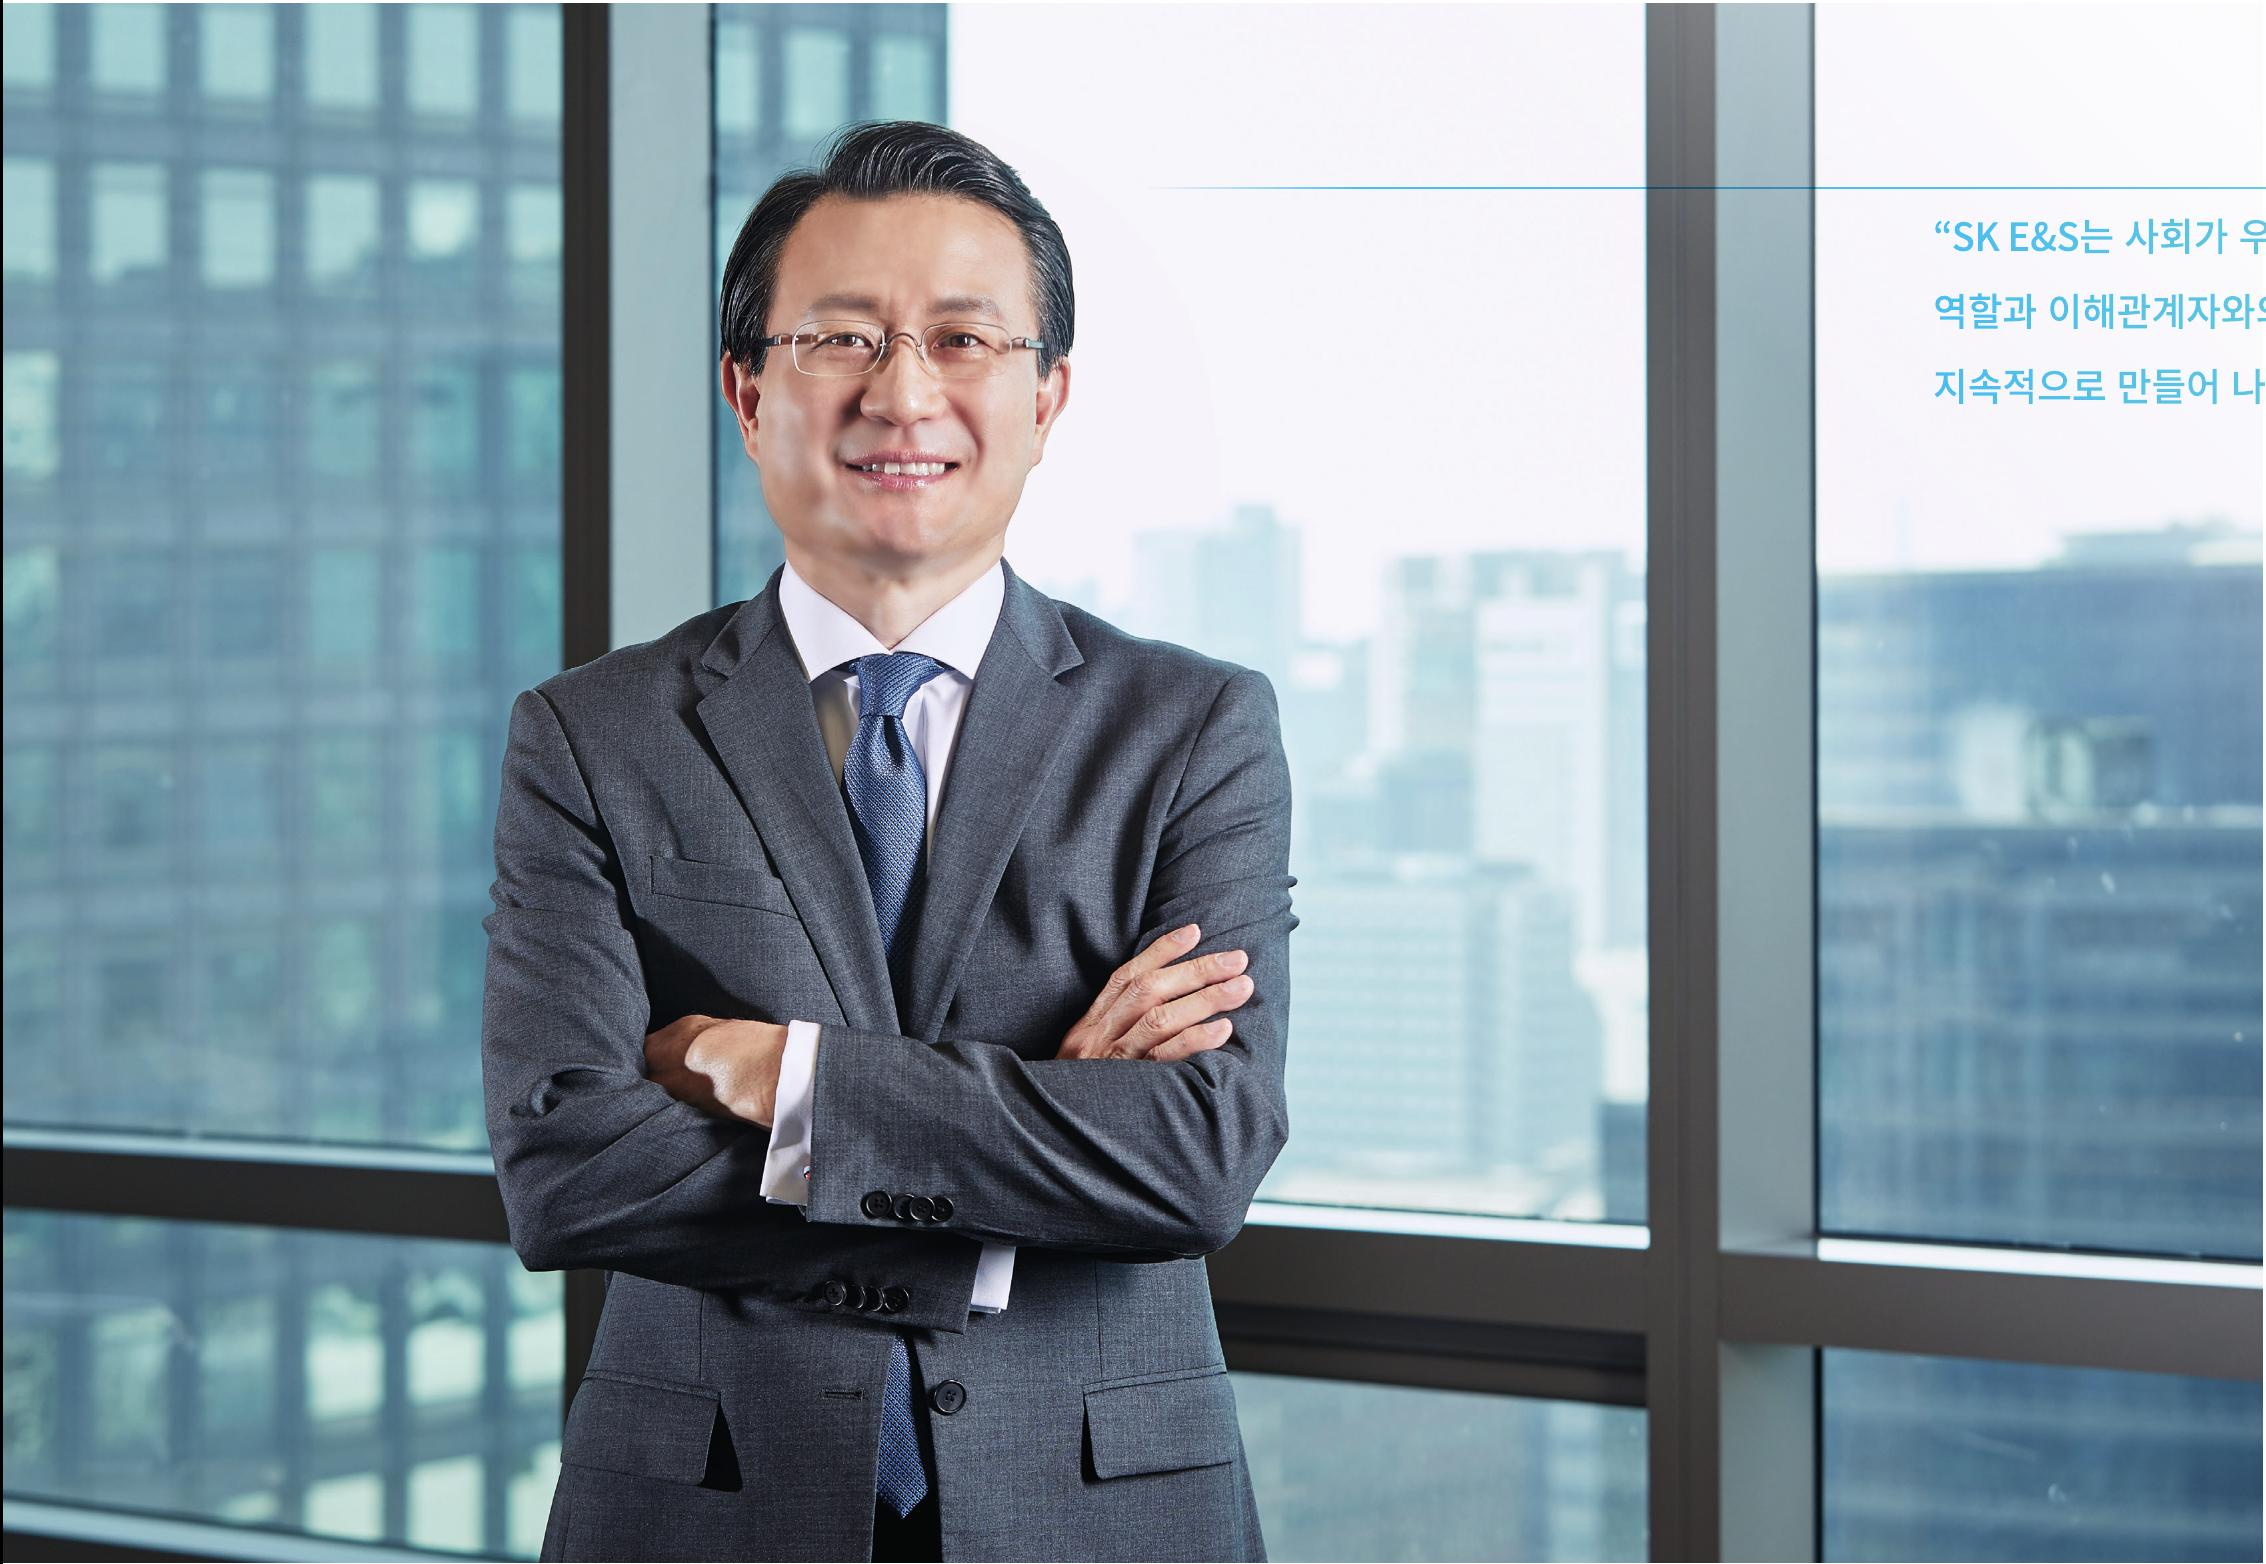


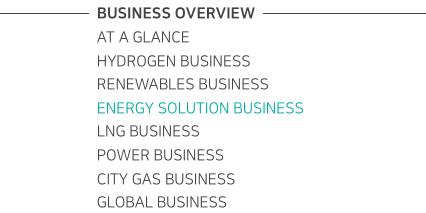


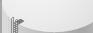

In [41]:
# 벡터 스토어에서 문서 검색 
docs = retriever.invoke("Businessman in a formal suit", k=40)

# 검색된 각 문서 처리
for doc in docs:
    # 문서 내용이 Base64 인코딩된 이미지인 경우
    if is_base64(doc.page_content):
        plt_img_base64(doc.page_content)  # 이미지 표시
        print("=" * 100)
    else:
        print(doc.page_content[:50])  # 텍스트 내용 출력
        print("=" * 100)

POWER BUSINESS

CITY GAS BUSINESS

천연가스 생산과정에서 발생하
CITY GAS BUSINESS

SK E&S는 전국 8개 지역, 총 456만 가구에 안전
부 산 정 관 에너지 인수

부산정관에너지 인수

2020년 말 인수한 부산정관에너지는 부
GREEN PORTFOLIO

:

：

:

수소 연 료 전지 발 전 을 통한 재 생 에
CEO MESSAGE

SK E&S는 지난 해 팬데믹의 지속적인 확산과 에너지 시장의 급격
풍력 발전

풍력 발전 전남 신안과 강원 평창에서 대규모 육상 풍력발전 프로젝트를 운영 중
수 소 에너지 사업

수소에너지 사업

9.9%

2 20211418 투 자 당시 기 준 
FINANCIAL STORY

SK E&S는 청정수소와 재생에너지, 에너지 솔루션, LNG
주 민 참여형 발 전 사 업

… _

주민참여형 발전사업 SK E&S가 추진하는 재생에너
———

CORPORATE SUSTAINABILITY ESG MANAGEMENT MILES
ESG MANAGEMENT

친환경 에너지 사업의 글로벌 리더로 도약하기 위해 ESG(En
국내 46 터 미 널 보유 현황

25

Join Eco, Be Energy, and Ma
GOVERNANCE ORGANIZATION

BUSINESS OVERVIEW AT A GL
미국 우 드 포드 프로젝트

미국 우드포드 프로젝트 2014년 Continental Res
미국 Plugit 지 분 투자

미국 Plug社 지분투자

SK E&S는 2021년 1월 
1999 - 2010

1999.1

SK, Enron 공동출자로 SK-Enron 설립


SK E&S 대 표 이사 부회장 유 정 준 / 대 표 이사 사장 추 형 욱

SK E&S 
미국

PRISM Energy International

7

7

United State
FSC®: Forest Stewardship Council®, 세계산림관리협의회

ECF:
RP A(VPP) 사업 진출

미국

미국 가상발전소(V


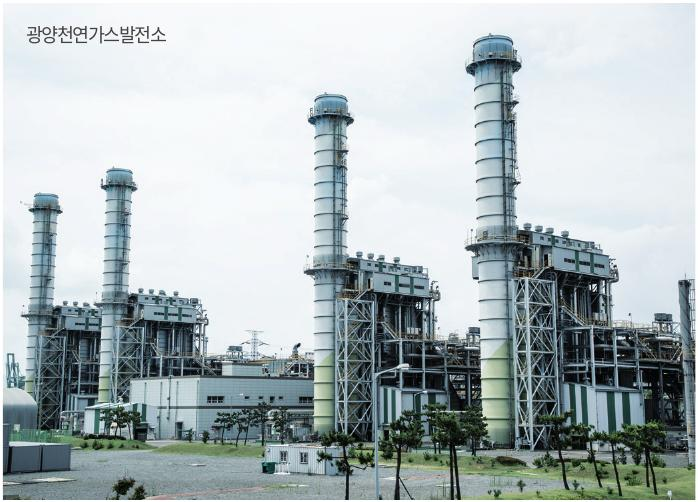


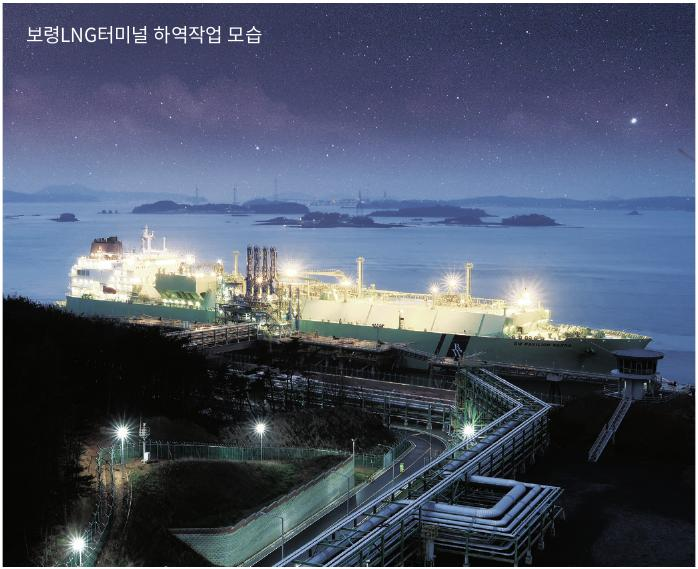


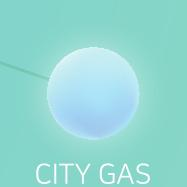


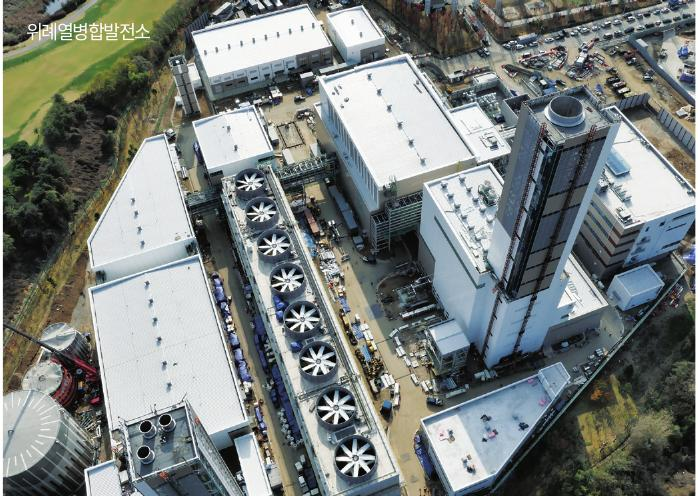


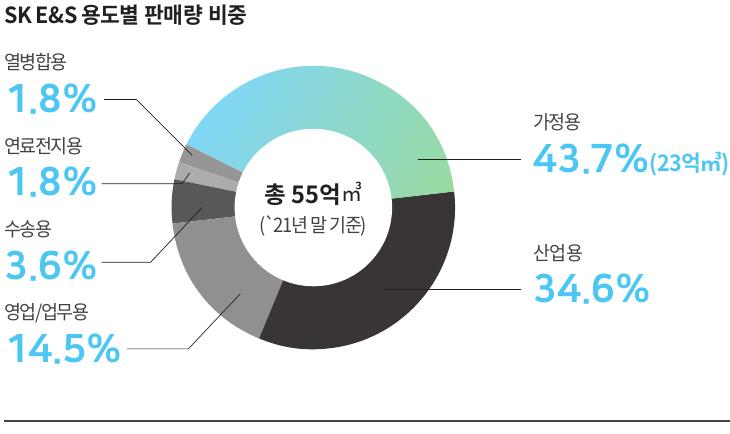


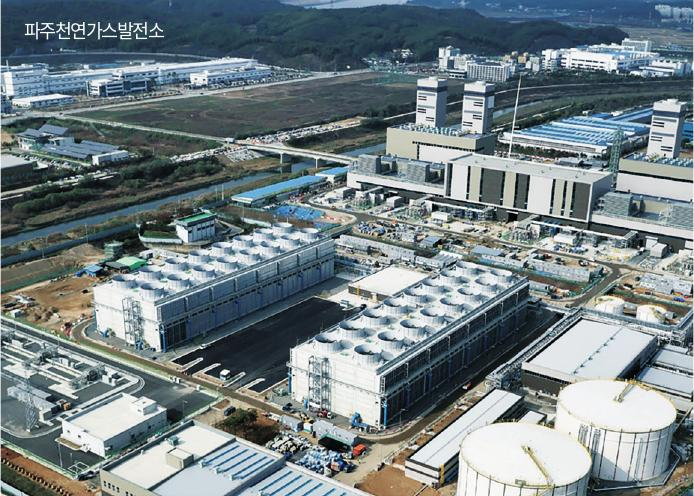


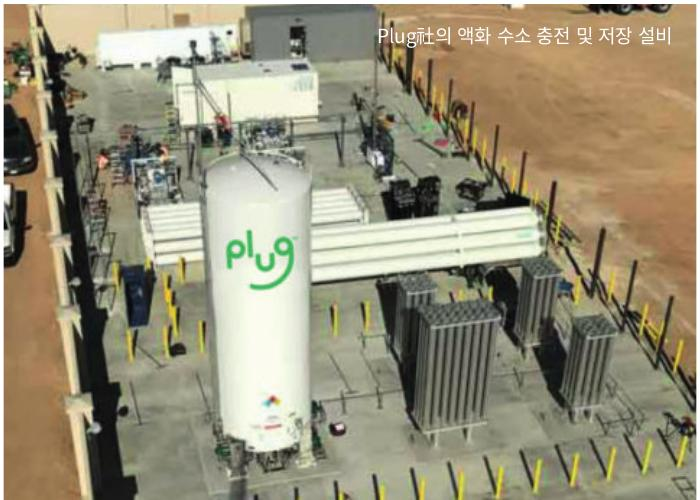


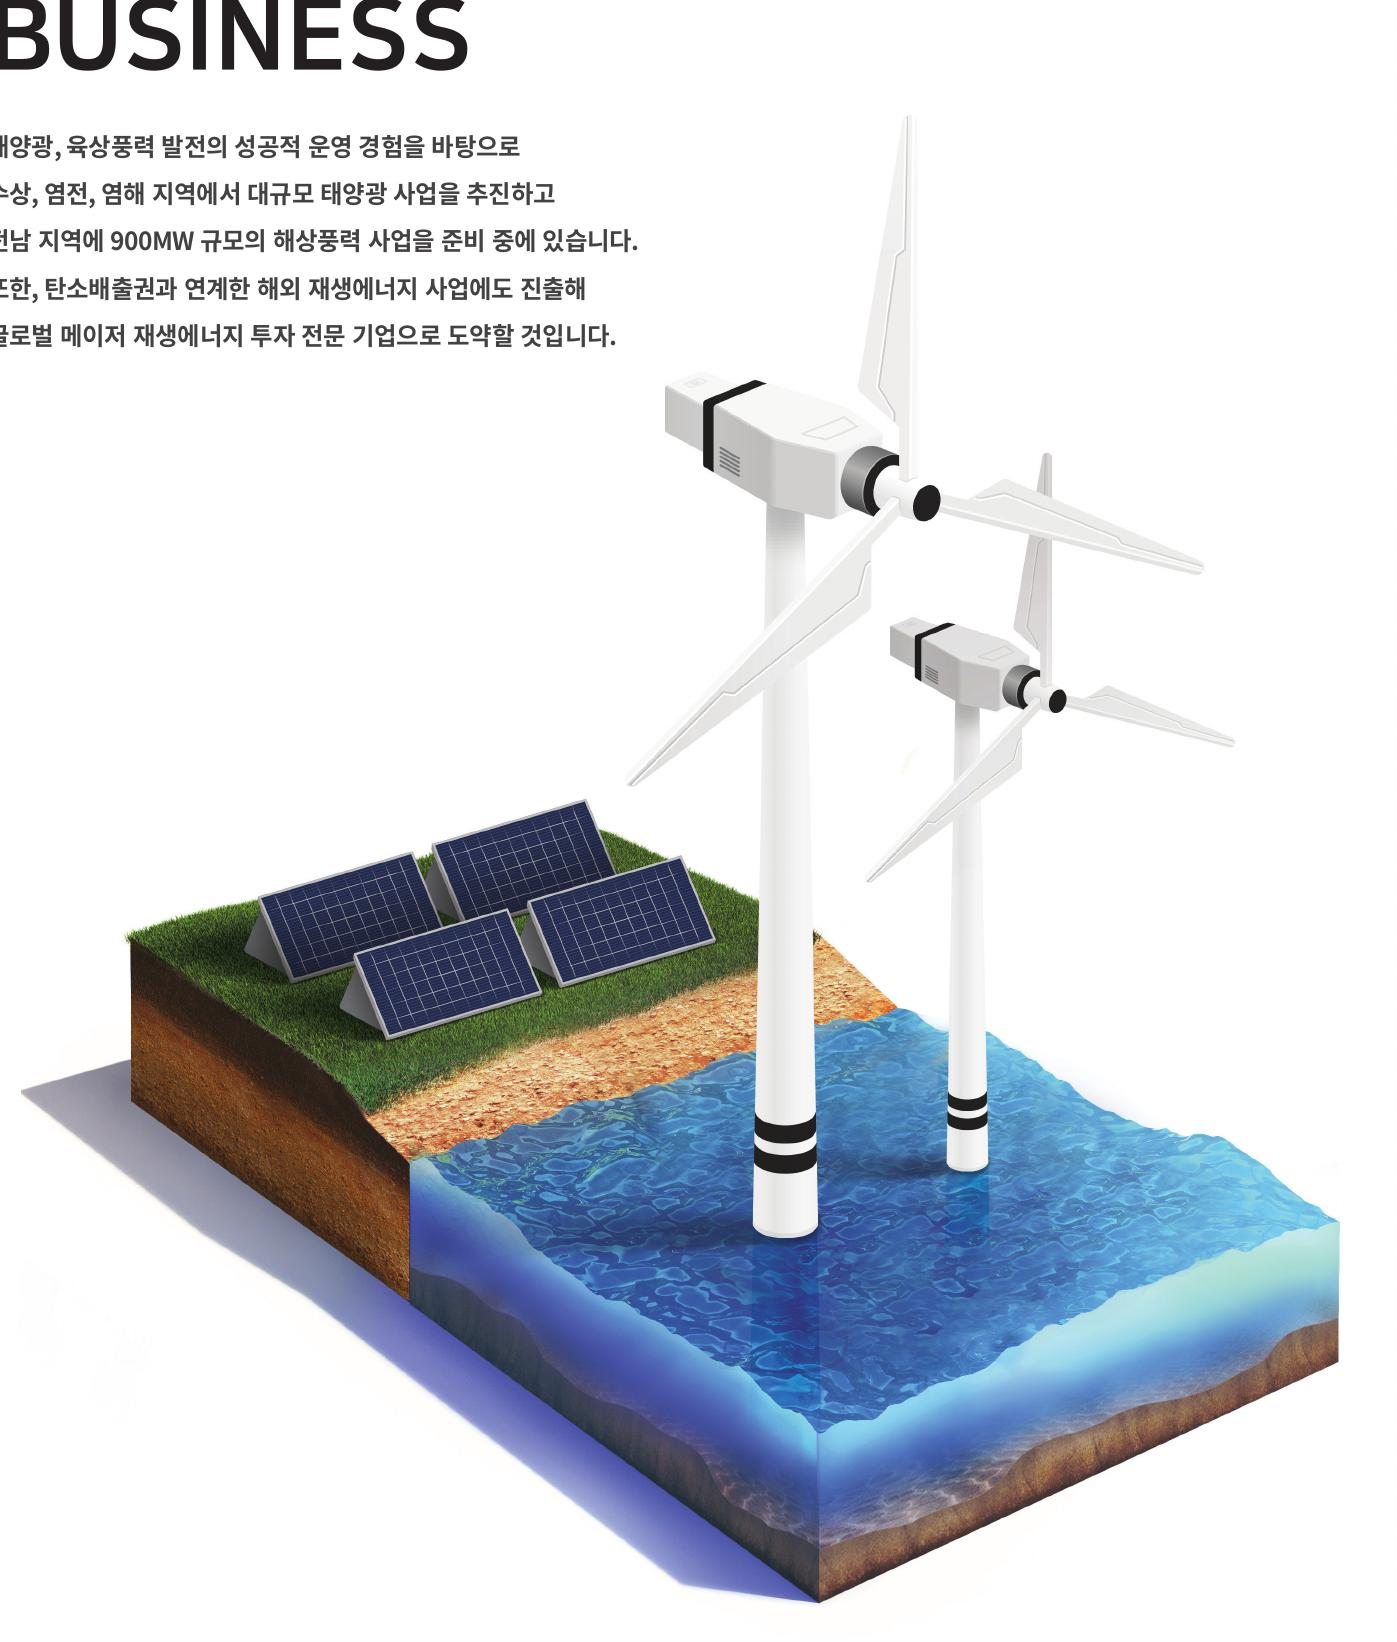


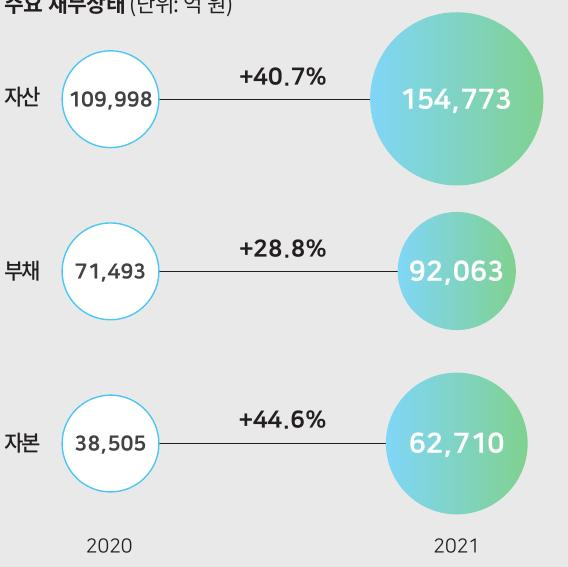


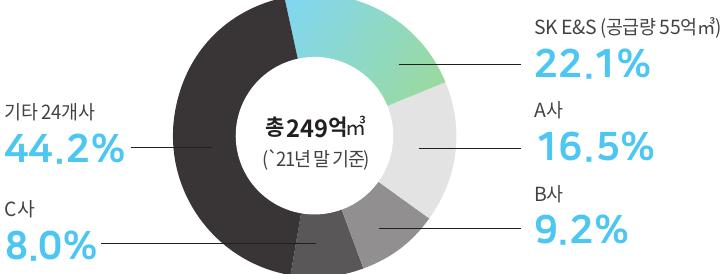


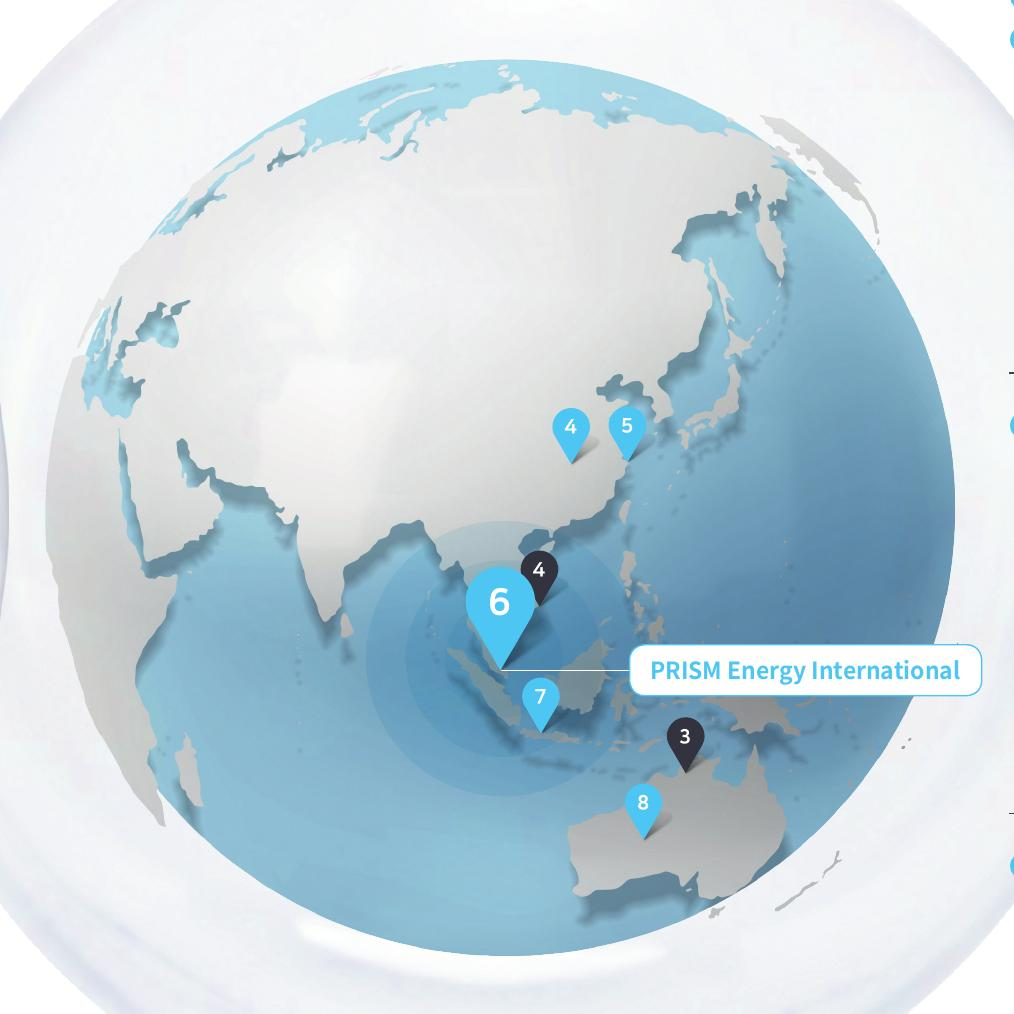


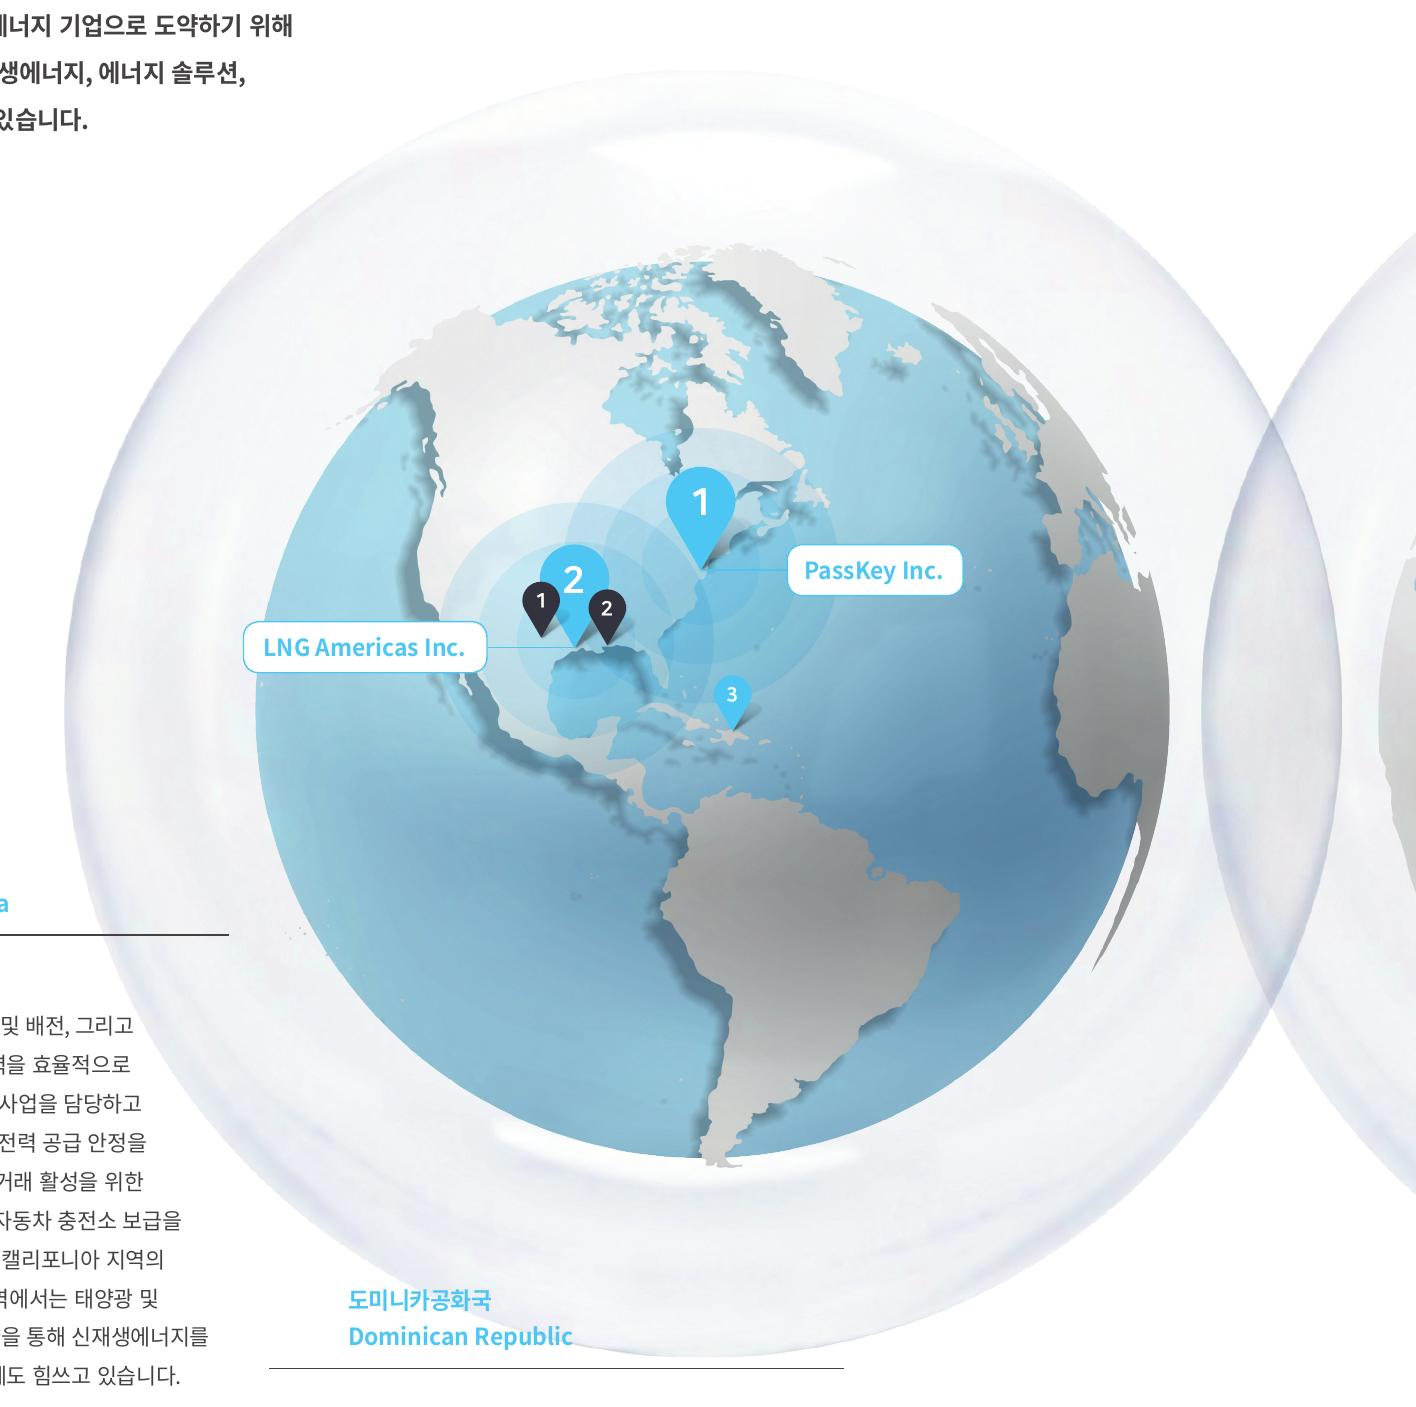


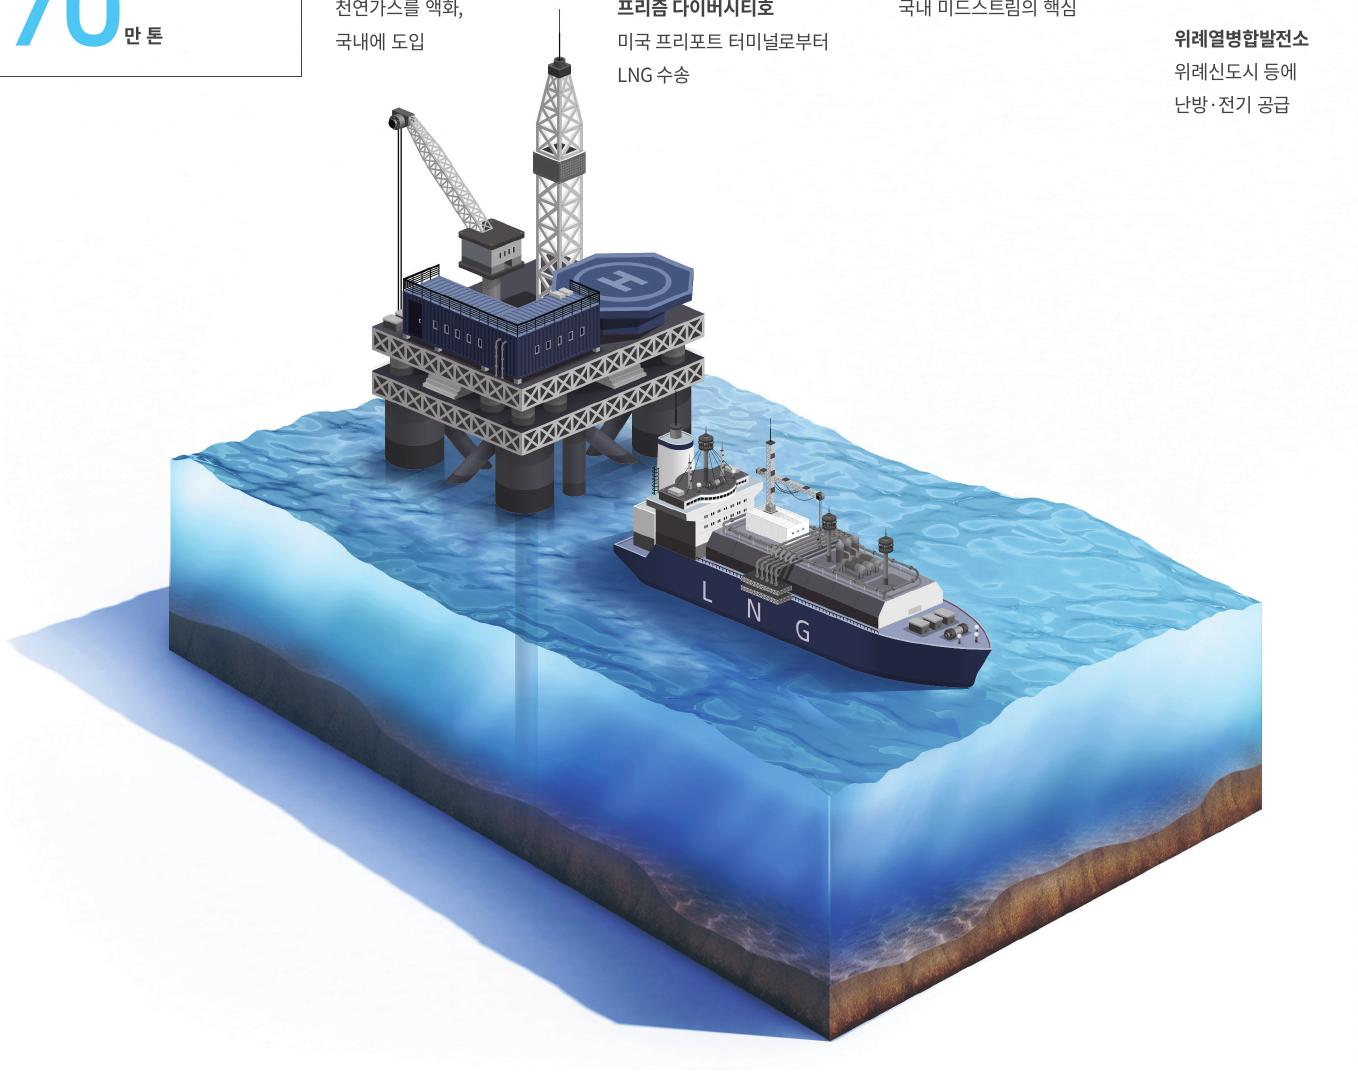

In [42]:
# 벡터 스토어에서 문서 검색 
docs = retriever.invoke("도시가스 사업 매출실적", k=40)

# 검색된 각 문서 처리
for doc in docs:
    # 문서 내용이 Base64 인코딩된 이미지인 경우
    if is_base64(doc.page_content):
        plt_img_base64(doc.page_content)  # 이미지 표시
        print("=" * 100)
    else:
        print(doc.page_content[:50])  # 텍스트 내용 출력
        print("=" * 100)

`(2) RAG 파이프라인`

- **prompt_func 함수**는 검색된 컨텍스트와 사용자 질문을 결합하여 모델에 전달할 **프롬프트**를 생성
- 파이프라인은 **검색 및 데이터 준비**와 **생성** 두 단계로 구성

In [43]:
from operator import itemgetter
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnableLambda, RunnablePassthrough
from langchain_openai import ChatOpenAI

def create_system_message():
    """
    시스템 메시지를 생성한다.
    반환값:
    SystemMessage: 재무 분석가 역할을 정의하는 시스템 메시지
    """
    system_content = (
        "당신은 재무 분석가이자 기업 평가 전문가이다. "
        "당신의 임무는 기업 보고서와 IR 자료를 분석하고 해석하는 것이다. "
        "이미지(차트, 그래프 등)와 함께 관련 텍스트가 제공되어 맥락을 제공할 것이다. "
        "이들은 모두 사용자 입력 키워드를 기반으로 벡터 스토어에서 검색된다. "
        "다음을 포함하는 포괄적인 분석을 제공하기 위해 재무 지식과 분석 기술을 활용한다:\n"
        "- 제시된 재무 데이터 및 시각 자료에 대한 상세한 설명\n"
        "- 기업의 현재 재무 상태와 시장 위치에 대한 분석\n"
        "- 주요 재무 지표의 추세 및 의미 해석\n"
        "- 잠재적 투자 기회 또는 위험 요소 식별\n"
        "- 동종 업계 내 경쟁사와의 비교 분석"
    )
    return SystemMessage(content=system_content)

def prompt_func(data_dict):
    """
    데이터 딕셔너리를 받아 모델에 전달할 프롬프트 메시지를 생성한다.
    매개변수:
    data_dict (dict): 컨텍스트와 질문을 포함하는 딕셔너리
    반환값:
    list: SystemMessage와 HumanMessage 객체를 포함하는 리스트
    """
    # 컨텍스트 텍스트를 하나의 문자열로 결합
    formatted_texts = "\n".join(data_dict["context"]["texts"])
    
    # 멀티모달 콘텐츠 리스트 생성
    content_blocks = []
    
    # 모든 이미지를 콘텐츠 블록에 추가
    if data_dict["context"]["images"]:
        for image_data in data_dict["context"]["images"]:
            image_block = {
                "type": "image_url",
                "image_url": {
                    "url": f"data:image/jpeg;base64,{image_data}"
                },
            }
            content_blocks.append(image_block)
    
    # 텍스트 콘텐츠 블록 추가
    text_content = (
        f"사용자 제공 키워드: {data_dict['question']}\n\n"
        "텍스트 및/또는 표:\n"
        f"{formatted_texts}"
    )
    
    text_block = {
        "type": "text",
        "text": text_content
    }
    content_blocks.append(text_block)
    
    # 시스템 메시지와 휴먼 메시지를 분리하여 반환
    return [
        create_system_message(),
        HumanMessage(content=content_blocks)
    ]

# GPT-4 멀티모달 모델 초기화 (수정: gpt-4.1-mini → gpt-4o-mini)
model = ChatOpenAI(temperature=0, model="gpt-4o-mini")

# RAG 파이프라인 구성
chain = (
    {
        "context": retriever | RunnableLambda(split_image_text_types),  # 검색된 데이터를 이미지와 텍스트로 분리
        "question": RunnablePassthrough(),  # 원본 질문을 그대로 전달
    }
    | RunnableLambda(prompt_func)  # 프롬프트 메시지 생성
    | model  # 모델에 프롬프트 전달
    | StrOutputParser()  # 모델 출력을 문자열로 변환
)

In [44]:
# chain 실행
result = chain.invoke("도시가스 사업 매출실적")

# 결과 출력
print(result)

### 도시가스 사업 매출실적 분석

#### 1. **재무 데이터 및 시각 자료 설명**
- **시장 점유율**: SK E&S는 국내 도시가스 시장에서 22.1%의 점유율을 기록하며, 7개의 도시가스 자회사를 통해 총 456만 가구에 도시가스를 공급하고 있습니다. 이는 국내 도시가스 공급 시장에서 1위의 위치를 차지하고 있음을 나타냅니다.
- **공급량**: SK E&S의 공급량은 55억㎥로, 이는 전체 도시가스 공급량 249억㎥ 중 상당한 비중을 차지합니다.
- **용도별 판매량 비중**: 가정용(43.7%), 산업용(34.6%), 영업/업무용(14.5%) 등 다양한 용도로 도시가스가 사용되고 있으며, 이는 안정적인 수익원으로 작용할 수 있습니다.

#### 2. **현재 재무 상태 및 시장 위치 분석**
- SK E&S는 도시가스 사업을 통해 안정적인 매출을 확보하고 있으며, 지속 가능한 에너지 솔루션을 제공하기 위해 사업 포트폴리오를 다양화하고 있습니다. 
- 도시가스 사업의 안정적인 수익 구조는 가정용 및 산업용 수요에 기반하고 있으며, 이는 경제적 불황에도 비교적 안정적인 매출을 유지할 수 있는 기반이 됩니다.

#### 3. **주요 재무 지표의 추세 및 의미 해석**
- **시장 점유율 증가**: SK E&S의 시장 점유율이 증가하고 있다는 것은 경쟁사 대비 우위를 점하고 있다는 것을 의미합니다. 이는 고객의 신뢰와 브랜드 인지도 증가로 이어질 수 있습니다.
- **용도별 판매량 비중**: 가정용 비중이 높은 것은 안정적인 수익원으로 작용하며, 산업용 비중도 상당하여 다양한 고객층을 확보하고 있음을 보여줍니다.

#### 4. **잠재적 투자 기회 또는 위험 요소 식별**
- **투자 기회**: SK E&S는 CCS(탄소 포집 및 저장) 기술을 활용한 저탄소 LNG 사업을 통해 친환경 에너지 시장에서의 경쟁력을 강화하고 있습니다. 이는 향후 ESG(환경, 사회, 지배구조) 투자자들에게 매력적인 요소가 될 수 있습니다.
- **위험 요소**: 도시

In [45]:
# chain 실행
result = chain.invoke("도시 가스 공장 설비 및 인프라에 대한 설명")

# 결과 출력
print(result)

### 도시 가스 공장 설비 및 인프라에 대한 분석

#### 1. 기업 개요 및 시장 위치
SK E&S는 도시가스 및 전력사업을 포함하여 신재생에너지와 수소사업을 운영하는 국내외 자회사를 보유하고 있습니다. 이 회사는 전국 8개 지역에 7개의 도시가스 자회사를 두고 있으며, 국내 도시가스 시장에서 1위를 차지하고 있습니다. 이는 SK E&S가 안정적인 시장 점유율을 확보하고 있음을 나타냅니다.

#### 2. 재무 데이터 및 시각 자료 분석
제공된 텍스트에 따르면, SK E&S는 저탄소 LNG 사업을 통해 이산화탄소를 포집·저장하는 CCS 기술을 활용하고 있습니다. 이는 환경 친화적인 에너지 생산을 위한 중요한 기술로, 기업의 지속 가능성을 높이는 데 기여하고 있습니다. 또한, 해외 가스전에서 생산된 천연가스를 국내에 도입하여 저비용·고효율의 전력을 안정적으로 공급하고 있습니다.

#### 3. 주요 재무 지표의 추세 및 의미 해석
- **저탄소 LNG 사업**: CCS 기술을 통해 이산화탄소를 줄이는 노력은 기업의 환경적 책임을 다하는 동시에, 정부의 친환경 정책에 부합하여 장기적으로 안정적인 수익을 창출할 수 있는 기반이 됩니다.
- **수소 사업**: 액화수소 생산기지와 청정 블루수소 생산 계획은 향후 수소 시장의 성장 가능성을 반영하고 있으며, 이는 SK E&S의 수익 다각화 전략의 일환으로 볼 수 있습니다.

#### 4. 잠재적 투자 기회 및 위험 요소
- **투자 기회**: SK E&S의 저탄소 LNG 및 수소 사업은 향후 에너지 시장에서의 성장 가능성을 높이며, 친환경 에너지에 대한 수요 증가에 따라 안정적인 수익을 기대할 수 있습니다.
- **위험 요소**: 에너지 시장의 변동성, 특히 천연가스 가격의 변동은 기업의 수익성에 직접적인 영향을 미칠 수 있습니다. 또한, 기술적 문제나 규제 변화가 CCS 및 수소 사업에 부정적인 영향을 미칠 수 있습니다.

#### 5. 동종 업계 내 경쟁사와의 비교 분석
SK E&S는 국내 도시가스 시장에서 1

---
## **[실습]**

- 트랜스포머 논문(data/transformer.pdf)에 대한 CLIP 임베딩 기반 RAG 시스템을 구현합니다. 

In [1]:
# 실습: Transformer 논문 RAG 구현
import os
from dotenv import load_dotenv
from huggingface_hub import snapshot_download

# 1. 환경 설정
load_dotenv()

# Poppler 및 Tesseract 경로 설정 (Windows 환경)
poppler_path = os.getenv("POPPLER_PATH", r"H:\miniconda3\envs\modu3\Library\bin")
tesseract_path = os.getenv("TESSERACT_PATH", r"H:\miniconda3\envs\modu3\Library\bin")

# PATH 환경변수에 추가
os.environ["PATH"] += os.pathsep + poppler_path
os.environ["PATH"] += os.pathsep + tesseract_path

# 2. PDF 파싱
from unstructured.partition.pdf import partition_pdf

pdf_path = "data/transformer.pdf"
print(f"Processing {pdf_path}...")

# PDF 파싱
# extract_images_in_pdf=False로 설정하여 텍스트/테이블 위주로 처리 (속도 및 안정성)
raw_pdf_elements = partition_pdf(
    filename=pdf_path,
    extract_images_in_pdf=False, 
    infer_table_structure=True,
    chunking_strategy="by_title",
    max_characters=4000,
    new_after_n_chars=3800,
    combine_text_under_n_chars=2000,
)
print(f"Extracted {len(raw_pdf_elements)} elements.")

# 3. 데이터 전처리
from langchain_core.documents import Document

documents = []
for element in raw_pdf_elements:
    metadata = element.metadata.to_dict()
    # 메타데이터 정리
    if "languages" in metadata: del metadata["languages"]
    if "source" in metadata: del metadata["source"]
    if "coordinates" in metadata: del metadata["coordinates"]
    
    documents.append(Document(page_content=element.text, metadata=metadata))

# 4. 임베딩 및 벡터 저장소
from langchain_experimental.open_clip import OpenCLIPEmbeddings
from langchain_chroma import Chroma

# CLIP 모델 로컬 다운로드 (snapshot_download 사용)
clip_model_dir = "./models/clip_vit_b32_laion2b"

if not os.path.exists(clip_model_dir):
    print("CLIP 모델 다운로드 중...")
    snapshot_download(
        repo_id="laion/CLIP-ViT-B-32-laion2B-s34B-b79K",
        local_dir=clip_model_dir,
        local_dir_use_symlinks=False
    )
    print("다운로드 완료!")
else:
    print(f"모델이 이미 존재합니다: {clip_model_dir}")

# 체크포인트 파일 자동 탐지
checkpoint_files = [
    f"{clip_model_dir}/open_clip_pytorch_model.bin",
    f"{clip_model_dir}/pytorch_model.bin",
    f"{clip_model_dir}/model.safetensors",
    f"{clip_model_dir}/open_clip_model.safetensors"
]

checkpoint_path = None
for cp_file in checkpoint_files:
    if os.path.exists(cp_file):
        checkpoint_path = cp_file
        print(f"체크포인트 파일 발견: {checkpoint_path}")
        break

if checkpoint_path is None:
    # 디렉토리 내 .bin 또는 .safetensors 파일 검색
    for f in os.listdir(clip_model_dir):
        if f.endswith('.bin') or f.endswith('.safetensors'):
            checkpoint_path = os.path.join(clip_model_dir, f)
            print(f"체크포인트 파일 발견: {checkpoint_path}")
            break

if checkpoint_path is None:
    raise FileNotFoundError(f"체크포인트 파일을 찾을 수 없습니다: {clip_model_dir}")

print("Initializing OpenCLIPEmbeddings with local checkpoint...")
embedding_model = OpenCLIPEmbeddings(
    model_name="ViT-B-32",
    checkpoint=checkpoint_path
)

print("Creating Vector Store...")
vectorstore = Chroma.from_documents(
    documents=documents,
    embedding=embedding_model,
    collection_name="transformer_paper_clip"
)

# 5. RAG 체인
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

template = """Answer the question based only on the following context:
{context}

Question: {question}
"""
prompt = ChatPromptTemplate.from_template(template)

retriever = vectorstore.as_retriever(search_kwargs={"k": 5})

def format_docs(docs):
    return "\n\n".join([d.page_content for d in docs])

chain = (
    {"context": retriever | format_docs, "question": RunnablePassthrough()}
    | prompt
    | llm
    | StrOutputParser()
)

# 6. 테스트
question = "What is the Transformer architecture?"
print(f"\nQuestion: {question}")
response = chain.invoke(question)
print(f"Answer: {response}")

Processing data/transformer.pdf...


W1122 10:00:09.089000 36200 site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.
The `max_size` parameter is deprecated and will be removed in v4.26. Please specify in `size['longest_edge'] instead`.


Extracted 14 elements.
모델이 이미 존재합니다: ./models/clip_vit_b32_laion2b
체크포인트 파일 발견: ./models/clip_vit_b32_laion2b/open_clip_model.safetensors
Initializing OpenCLIPEmbeddings with local checkpoint...
Creating Vector Store...

Question: What is the Transformer architecture?
Answer: The Transformer architecture is a sequence transduction model that relies entirely on attention mechanisms, eliminating the need for recurrent or convolutional layers commonly used in encoder-decoder architectures. It utilizes multi-headed self-attention to draw global dependencies between input and output sequences, allowing for significantly more parallelization during training. The Transformer has been shown to achieve state-of-the-art results in machine translation tasks, such as English-to-German and English-to-French, while requiring less training time compared to traditional models. Additionally, it incorporates position-wise feed-forward networks, learned embeddings, and positional encodings to effectively